In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import shap
import xgboost as xgb
from sklearn.experimental     import enable_iterative_imputer
from sklearn.impute           import IterativeImputer, SimpleImputer
from sklearn.linear_model     import LinearRegression
from sklearn.model_selection  import GroupKFold, GridSearchCV, cross_val_score, PredefinedSplit
from sklearn.metrics          import r2_score, mean_absolute_error, mean_squared_error
from sklearn.feature_selection import mutual_info_regression

BLUE   = '#1C7293'
GREEN  = '#02C39A'
ORANGE = '#F4845F'
PURPLE = '#7B5EA7'
GRAY   = '#636E72'
RED    = '#D62828'

plt.rcParams.update({
    'figure.dpi'       : 130,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})

# Load Data

In [15]:
df = pd.read_csv('final_dataset_fixed.csv')

print(f'Rows: {len(df)}  |  Counties: {df["fips"].nunique()}  |  Years: {sorted(df["Year"].unique())}')
print()

# Retained predictors used across the models.
# Use transformed versions rather than the corresponding raw variables.
MODEL_PREDICTORS = [
    'log_EV_Count',                # log(EV station count + 1)
    'EV_per_100k',                 # population-normalised EV measure
    'log_DVMT',                    # log(daily vehicle miles travelled + 1)
    'log_Population_Density',      # log(population density + 1)
    'median_income',               # socioeconomic control
    'Year',                        # time control used in the models
]

MODEL_TARGETS = [
    'log_Price_Q50',               # price-model target
    'NO2_Q50',                     # air-quality-model target
]

# Columns passed to MICE. Targets are included so MICE can use the joint
# relationships among all modelling variables, but each target is used only
# as an outcome in its corresponding model later.
MODEL_FEATURES_ALL = MODEL_PREDICTORS + MODEL_TARGETS

missing_columns = [col for col in MODEL_FEATURES_ALL if col not in df.columns]
if missing_columns:
    raise KeyError(f'Missing required columns: {missing_columns}')

print('Missing values in retained predictors and targets:')
for col in MODEL_FEATURES_ALL:
    n = df[col].isnull().sum()
    print(f'  {col:<26}: {n} missing')

print()
print('Excluded from modelling:')
print('  Raw versions replaced by logs: EV_Count, DVMT, Population_Density')
print('  Removed after correlation/VIF: log_Population, log_Land_Area')
print('  Identifiers: fips, StateCodeFIPS, EPA_County_Code, MunicipalCodeFIPS')
print('  Other target summaries: Price_Q25, Price_Q50, Price_Q75,')
print('                          NO2_Q25, NO2_Q75, NO2_Mean, NO2_Peak')

print()
print('Non-model columns with structural missingness:')
for col in ['EV_Growth_Rate', 'Price_Growth_Pct']:
    if col in df.columns:
        print(f'  {col:<26}: {df[col].isnull().sum()} missing — NOT used as a model feature')

Rows: 628  |  Counties: 242  |  Years: [np.int64(2023), np.int64(2024), np.int64(2025)]

Missing values in retained predictors and targets:
  log_EV_Count              : 0 missing
  EV_per_100k               : 0 missing
  log_DVMT                  : 0 missing
  log_Population_Density    : 0 missing
  median_income             : 0 missing
  Year                      : 0 missing
  log_Price_Q50             : 0 missing
  NO2_Q50                   : 0 missing

Excluded from modelling:
  Raw versions replaced by logs: EV_Count, DVMT, Population_Density
  Removed after correlation/VIF: log_Population, log_Land_Area
  Identifiers: fips, StateCodeFIPS, EPA_County_Code, MunicipalCodeFIPS
  Other target summaries: Price_Q25, Price_Q50, Price_Q75,
                          NO2_Q25, NO2_Q75, NO2_Mean, NO2_Peak

Non-model columns with structural missingness:
  EV_Growth_Rate            : 232 missing — NOT used as a model feature
  Price_Growth_Pct          : 205 missing — NOT used as a model featur

# Feasibility: Scatter Plots + Group Comparison

,N,Median_LogEV,Median_EV_per_100k,Mean_LogPrice,Mean_NO2
EV_Class,,,,,
Low EV,222,1.098612,1.818862,12.537549,3.892239
Mid EV,202,2.708050,2.909859,12.828553,6.285977
High EV,204,4.060443,5.004397,13.087293,7.883025


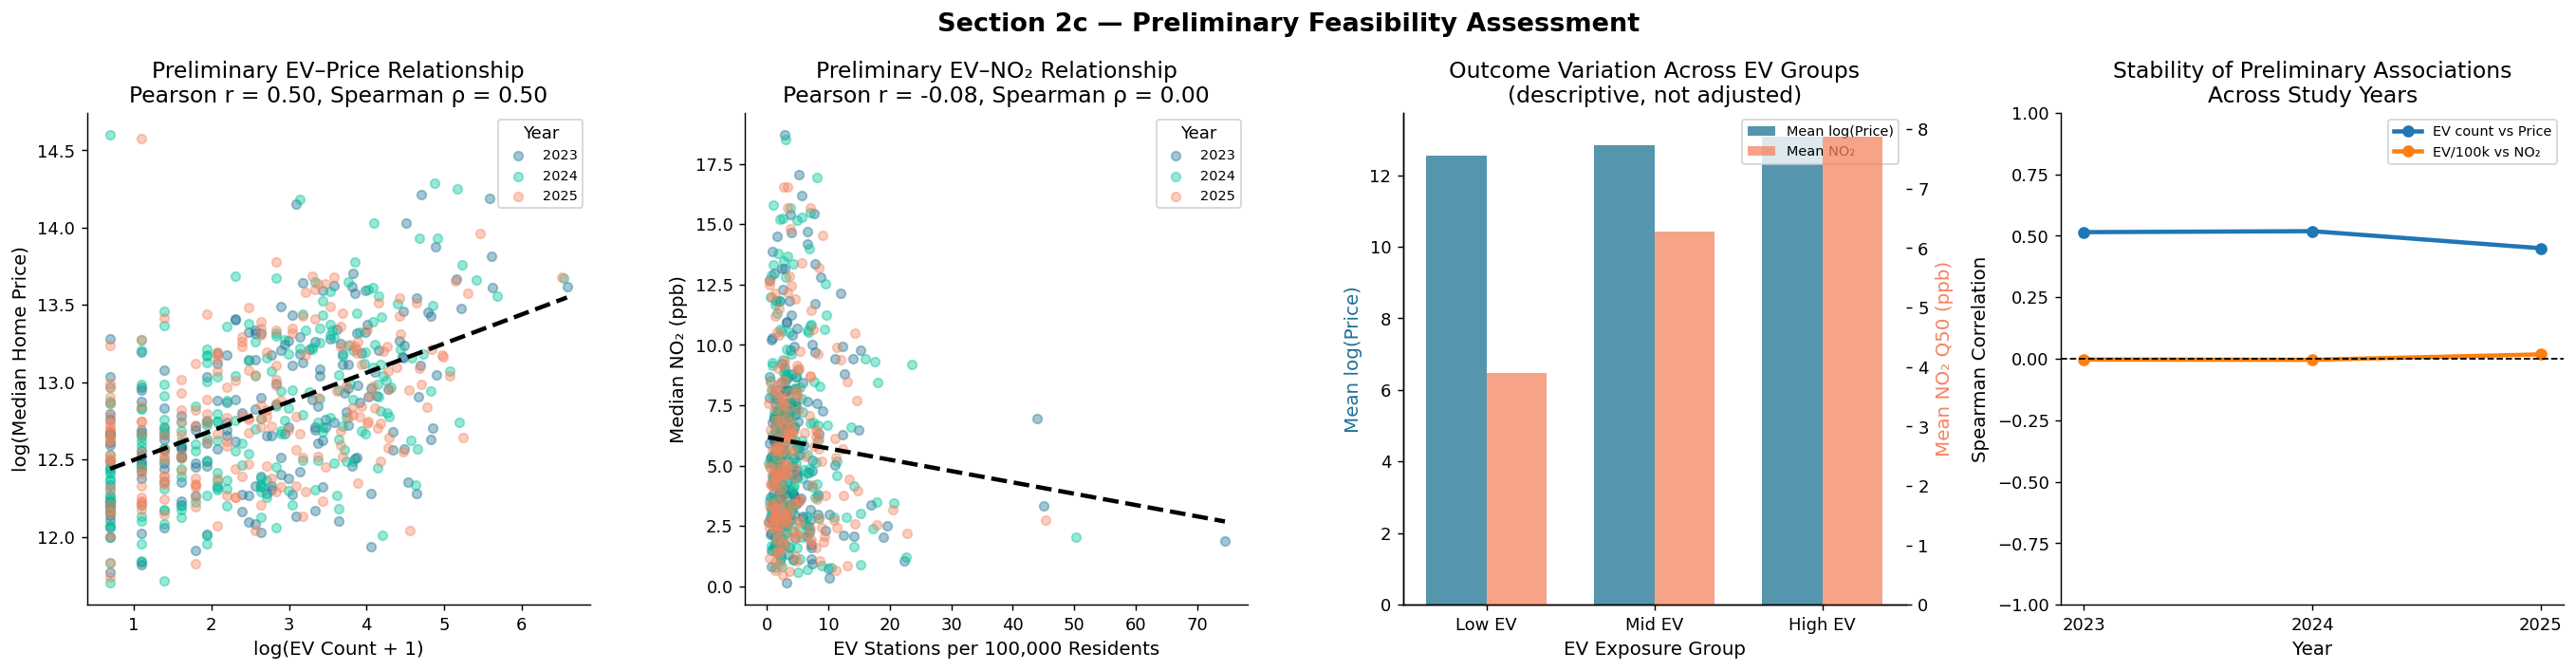

FEASIBILITY SUMMARY
-------------------------------------------------------
Complete observations used: 628
Years represented: [np.int64(2023), np.int64(2024), np.int64(2025)]

Variation in main variables:
  log_EV_Count range: 0.69 to 6.58
  EV_per_100k range: 0.20 to 74.50
  log_Price_Q50 range: 11.71 to 14.60
  NO2_Q50 range: 0.17 to 18.69

Preliminary unadjusted associations:
  log(EV Count) vs log(Price): Pearson r = +0.501, p = 2.951e-41
  log(EV Count) vs log(Price): Spearman rho = +0.496, p = 2.751e-40
  EV per 100k vs NO2: Pearson r = -0.076, p = 0.05846
  EV per 100k vs NO2: Spearman rho = +0.004, p = 0.9298


In [16]:
# ============================================================
# Feasibility Assessment
# ============================================================

from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Variables used in the preliminary feasibility analysis
feasibility_cols = [
    "log_EV_Count",
    "EV_per_100k",
    "log_Price_Q50",
    "NO2_Q50",
    "Year"
]

feas_df = df[feasibility_cols].dropna().copy()

# Create EV exposure groups using the transformed EV count
# duplicates="drop" prevents errors if several quantile boundaries are identical
feas_df["EV_Class"] = pd.qcut(
    feas_df["log_EV_Count"],
    q=3,
    labels=["Low EV", "Mid EV", "High EV"],
    duplicates="drop"
)

ev_order = ["Low EV", "Mid EV", "High EV"]

group_summary = (
    feas_df
    .groupby("EV_Class", observed=True)
    .agg(
        N=("log_EV_Count", "size"),
        Median_LogEV=("log_EV_Count", "median"),
        Median_EV_per_100k=("EV_per_100k", "median"),
        Mean_LogPrice=("log_Price_Q50", "mean"),
        Mean_NO2=("NO2_Q50", "mean")
    )
    .reindex(ev_order)
)

display(group_summary)

# ------------------------------------------------------------
# Overall preliminary associations
# ------------------------------------------------------------

price_pearson_r, price_pearson_p = pearsonr(
    feas_df["log_EV_Count"],
    feas_df["log_Price_Q50"]
)

price_spearman_r, price_spearman_p = spearmanr(
    feas_df["log_EV_Count"],
    feas_df["log_Price_Q50"]
)

no2_pearson_r, no2_pearson_p = pearsonr(
    feas_df["EV_per_100k"],
    feas_df["NO2_Q50"]
)

no2_spearman_r, no2_spearman_p = spearmanr(
    feas_df["EV_per_100k"],
    feas_df["NO2_Q50"]
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 4, figsize=(21, 5.5))

fig.suptitle(
    "Section 2c — Preliminary Feasibility Assessment",
    fontsize=15,
    fontweight="bold"
)

year_pal = {
    2023: BLUE,
    2024: GREEN,
    2025: ORANGE
}

# ------------------------------------------------------------
# Panel 1: EV count and home price
# ------------------------------------------------------------

for year, group in feas_df.groupby("Year"):
    axes[0].scatter(
        group["log_EV_Count"],
        group["log_Price_Q50"],
        alpha=0.40,
        s=28,
        color=year_pal.get(year),
        label=str(year)
    )

x_price = feas_df["log_EV_Count"].to_numpy()
y_price = feas_df["log_Price_Q50"].to_numpy()

price_slope, price_intercept = np.polyfit(x_price, y_price, 1)

price_grid = np.linspace(x_price.min(), x_price.max(), 200)

axes[0].plot(
    price_grid,
    price_slope * price_grid + price_intercept,
    color="black",
    linewidth=2.5,
    linestyle="--"
)

axes[0].set_title(
    "Preliminary EV–Price Relationship\n"
    f"Pearson r = {price_pearson_r:.2f}, "
    f"Spearman ρ = {price_spearman_r:.2f}"
)

axes[0].set_xlabel("log(EV Count + 1)")
axes[0].set_ylabel("log(Median Home Price)")
axes[0].legend(title="Year", fontsize=8)

# ------------------------------------------------------------
# Panel 2: EV per 100k and NO2
# ------------------------------------------------------------

for year, group in feas_df.groupby("Year"):
    axes[1].scatter(
        group["EV_per_100k"],
        group["NO2_Q50"],
        alpha=0.40,
        s=28,
        color=year_pal.get(year),
        label=str(year)
    )

x_no2 = feas_df["EV_per_100k"].to_numpy()
y_no2 = feas_df["NO2_Q50"].to_numpy()

no2_slope, no2_intercept = np.polyfit(x_no2, y_no2, 1)

no2_grid = np.linspace(x_no2.min(), x_no2.max(), 200)

axes[1].plot(
    no2_grid,
    no2_slope * no2_grid + no2_intercept,
    color="black",
    linewidth=2.5,
    linestyle="--"
)

axes[1].set_title(
    "Preliminary EV–NO₂ Relationship\n"
    f"Pearson r = {no2_pearson_r:.2f}, "
    f"Spearman ρ = {no2_spearman_r:.2f}"
)

axes[1].set_xlabel("EV Stations per 100,000 Residents")
axes[1].set_ylabel("Median NO₂ (ppb)")
axes[1].legend(title="Year", fontsize=8)

# ------------------------------------------------------------
# Panel 3: Outcomes across EV exposure groups
# ------------------------------------------------------------

x_positions = np.arange(len(ev_order))

price_by_group = group_summary["Mean_LogPrice"]
no2_by_group = group_summary["Mean_NO2"]

ax3_price = axes[2]
ax3_no2 = ax3_price.twinx()

width = 0.36

price_bars = ax3_price.bar(
    x_positions - width / 2,
    price_by_group,
    width=width,
    color=BLUE,
    alpha=0.75,
    label="Mean log(Price)"
)

no2_bars = ax3_no2.bar(
    x_positions + width / 2,
    no2_by_group,
    width=width,
    color=ORANGE,
    alpha=0.75,
    label="Mean NO₂"
)

ax3_price.set_xticks(x_positions)
ax3_price.set_xticklabels(ev_order)

ax3_price.set_xlabel("EV Exposure Group")
ax3_price.set_ylabel("Mean log(Price)", color=BLUE)
ax3_no2.set_ylabel("Mean NO₂ Q50 (ppb)", color=ORANGE)

ax3_price.set_title(
    "Outcome Variation Across EV Groups\n"
    "(descriptive, not adjusted)"
)

handles1, labels1 = ax3_price.get_legend_handles_labels()
handles2, labels2 = ax3_no2.get_legend_handles_labels()

ax3_price.legend(
    handles1 + handles2,
    labels1 + labels2,
    fontsize=8,
    loc="best"
)

# ------------------------------------------------------------
# Panel 4: Association stability across years
# ------------------------------------------------------------

year_results = []

for year, group in feas_df.groupby("Year"):

    price_r = group[
        ["log_EV_Count", "log_Price_Q50"]
    ].corr(method="spearman").iloc[0, 1]

    no2_r = group[
        ["EV_per_100k", "NO2_Q50"]
    ].corr(method="spearman").iloc[0, 1]

    year_results.append({
        "Year": year,
        "EV_Price_Spearman": price_r,
        "EV_NO2_Spearman": no2_r,
        "N": len(group)
    })

year_results = pd.DataFrame(year_results).sort_values("Year")

axes[3].plot(
    year_results["Year"].astype(str),
    year_results["EV_Price_Spearman"],
    marker="o",
    linewidth=2.5,
    label="EV count vs Price"
)

axes[3].plot(
    year_results["Year"].astype(str),
    year_results["EV_NO2_Spearman"],
    marker="o",
    linewidth=2.5,
    label="EV/100k vs NO₂"
)

axes[3].axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="--"
)

axes[3].set_ylim(-1, 1)
axes[3].set_xlabel("Year")
axes[3].set_ylabel("Spearman Correlation")
axes[3].set_title(
    "Stability of Preliminary Associations\n"
    "Across Study Years"
)
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Feasibility summary
# ------------------------------------------------------------

print("FEASIBILITY SUMMARY")
print("-" * 55)

print(f"Complete observations used: {len(feas_df)}")
print(f"Years represented: {sorted(feas_df['Year'].unique())}")

print()
print("Variation in main variables:")
print(
    f"  log_EV_Count range: "
    f"{feas_df['log_EV_Count'].min():.2f} to "
    f"{feas_df['log_EV_Count'].max():.2f}"
)
print(
    f"  EV_per_100k range: "
    f"{feas_df['EV_per_100k'].min():.2f} to "
    f"{feas_df['EV_per_100k'].max():.2f}"
)
print(
    f"  log_Price_Q50 range: "
    f"{feas_df['log_Price_Q50'].min():.2f} to "
    f"{feas_df['log_Price_Q50'].max():.2f}"
)
print(
    f"  NO2_Q50 range: "
    f"{feas_df['NO2_Q50'].min():.2f} to "
    f"{feas_df['NO2_Q50'].max():.2f}"
)

print()
print("Preliminary unadjusted associations:")
print(
    f"  log(EV Count) vs log(Price): "
    f"Pearson r = {price_pearson_r:+.3f}, "
    f"p = {price_pearson_p:.4g}"
)
print(
    f"  log(EV Count) vs log(Price): "
    f"Spearman rho = {price_spearman_r:+.3f}, "
    f"p = {price_spearman_p:.4g}"
)
print(
    f"  EV per 100k vs NO2: "
    f"Pearson r = {no2_pearson_r:+.3f}, "
    f"p = {no2_pearson_p:.4g}"
)
print(
    f"  EV per 100k vs NO2: "
    f"Spearman rho = {no2_spearman_r:+.3f}, "
    f"p = {no2_spearman_p:.4g}"
)

---
# MICE Imputation: Apply MICE to Training & Test Data



In [17]:
# ── Leak-free train/test split ─────────────────────────────────────────────
# MAIN SPLIT
#   Train: 2023+2024 rows from 80% of counties
#   Test:  2025 rows from remaining 20% of counties (completely unseen)
# TEMPORAL SPLIT (reuses same county pools)
#   Train:    train-pool counties x 2023
#   Validate: train-pool counties x 2024  (same counties, forward in time)
#   Test:     test-pool  counties x 2025  (completely unseen)

np.random.seed(42)
has_2025      = set(df[df['Year']==2025]['fips'].unique())
has_train_yrs = set(df[df['Year'].isin([2023,2024])]['fips'].unique())
both          = has_2025 & has_train_yrs
only_train    = has_train_yrs - has_2025
only_2025     = has_2025 - has_train_yrs
both_list     = sorted(both); np.random.shuffle(both_list)
cut = int(0.8*len(both_list))
train_counties = only_train | set(both_list[:cut])
test_counties  = only_2025  | set(both_list[cut:])

# Main split dataframes
train_df = df[(df['fips'].isin(train_counties)) & df['Year'].isin([2023,2024])].copy()
test_df  = df[(df['fips'].isin(test_counties))  & (df['Year']==2025)].copy()

# Temporal split dataframes (same county pools)
train_t_df = df[(df['fips'].isin(train_counties)) & (df['Year']==2023)].copy()
val_t_df   = df[(df['fips'].isin(train_counties)) & (df['Year']==2024)].copy()
test_t_df  = df[(df['fips'].isin(test_counties))  & (df['Year']==2025)].copy()

print('MAIN SPLIT:')
print(f'  Train: {len(train_df)} rows | {len(train_counties)} counties | years 2023-2024')
print(f'  Test:  {len(test_df)} rows  | {len(test_counties)} counties  | year 2025 only')
print(f'  County overlap: {len(set(train_df.fips) & set(test_df.fips))}  <- must be 0')
print()
print('TEMPORAL SPLIT:')
print(f'  Train:    {len(train_t_df)} rows | {train_t_df["fips"].nunique()} counties | year 2023')
print(f'  Validate: {len(val_t_df)} rows | {val_t_df["fips"].nunique()} counties | year 2024')
print(f'  Test:     {len(test_t_df)} rows  | {test_t_df["fips"].nunique()} counties  | year 2025')
print(f'  Train/Val overlap:  {len(set(train_t_df.fips) & set(val_t_df.fips))}  <- intentional (temporal)')
print(f'  Train/Test overlap: {len(set(train_t_df.fips) & set(test_t_df.fips))}  <- must be 0')
print(f'  Val/Test overlap:   {len(set(val_t_df.fips) & set(test_t_df.fips))}  <- must be 0')
print()

# ── Apply MICE to retained transformed predictors + targets ─────────────────
# Fit on training data only, then transform validation/test data to prevent leakage.
# Main split MICE
mice_final = IterativeImputer(max_iter=10, random_state=42)
train_imputed = pd.DataFrame(
    mice_final.fit_transform(train_df[MODEL_FEATURES_ALL]),
    columns=MODEL_FEATURES_ALL, index=train_df.index
)
test_imputed = pd.DataFrame(
    mice_final.transform(test_df[MODEL_FEATURES_ALL]),
    columns=MODEL_FEATURES_ALL, index=test_df.index
)
train_imputed['fips'] = train_df['fips'].values
test_imputed['fips']  = test_df['fips'].values

# Temporal split MICE (fit on 2023 train only)
mice_t = IterativeImputer(max_iter=10, random_state=42)
train_t_imputed = pd.DataFrame(
    mice_t.fit_transform(train_t_df[MODEL_FEATURES_ALL]),
    columns=MODEL_FEATURES_ALL, index=train_t_df.index
)
val_t_imputed = pd.DataFrame(
    mice_t.transform(val_t_df[MODEL_FEATURES_ALL]),
    columns=MODEL_FEATURES_ALL, index=val_t_df.index
)
test_t_imputed = pd.DataFrame(
    mice_t.transform(test_t_df[MODEL_FEATURES_ALL]),
    columns=MODEL_FEATURES_ALL, index=test_t_df.index
)
train_t_imputed['fips'] = train_t_df['fips'].values
val_t_imputed['fips']   = val_t_df['fips'].values
test_t_imputed['fips']  = test_t_df['fips'].values

print('MICE applied. Missing after imputation:')
print(f'  Main     Train: {train_imputed[MODEL_FEATURES_ALL].isnull().sum().sum()}')
print(f'  Main     Test:  {test_imputed[MODEL_FEATURES_ALL].isnull().sum().sum()}')
print(f'  Temporal Train: {train_t_imputed[MODEL_FEATURES_ALL].isnull().sum().sum()}')
print(f'  Temporal Val:   {val_t_imputed[MODEL_FEATURES_ALL].isnull().sum().sum()}')
print(f'  Temporal Test:  {test_t_imputed[MODEL_FEATURES_ALL].isnull().sum().sum()}')


MAIN SPLIT:
  Train: 355 rows | 194 counties | years 2023-2024
  Test:  48 rows  | 48 counties  | year 2025 only
  County overlap: 0  <- must be 0

TEMPORAL SPLIT:
  Train:    173 rows | 173 counties | year 2023
  Validate: 182 rows | 182 counties | year 2024
  Test:     48 rows  | 48 counties  | year 2025
  Train/Val overlap:  161  <- intentional (temporal)
  Train/Test overlap: 0  <- must be 0
  Val/Test overlap:   0  <- must be 0

MICE applied. Missing after imputation:
  Main     Train: 0
  Main     Test:  0
  Temporal Train: 0
  Temporal Val:   0
  Temporal Test:  0


---
## Section 3 — Feature Selection

We use **three complementary methods**. Each gives a different perspective — all three agreeing on the same features is a strong finding.

| Method | What it measures | Why useful |
|---|---|---|
| Mutual Information | Statistical dependence (linear + non-linear) | Model-agnostic; catches any relationship |
| XGBoost SHAP | Actual contribution per feature in trained model | Directional; model-specific |
| LR Coefficients | Linear contribution + direction | Interpretable; shows sign |

Each model has **3 inputs** (EV feature + log_Population + Year) — already a lean set, so feature selection confirms we haven't missed anything rather than drastically reducing features.

# Models Inputs

In [18]:
# Both models use the same predictor set.
# The only difference between the models is the prediction target.
#
# log_EV_Count      : absolute EV infrastructure
# EV_per_100k       : EV infrastructure normalized by population
# log_DVMT          : traffic intensity
# log_Population_Density : degree of urbanization
# median_income     : socioeconomic status
# Year              : temporal trend

MODEL_CONFIGS = {
    'House Price Model': {
        'features': [
            'log_EV_Count',
            'EV_per_100k',
            'log_DVMT',
            'log_Population_Density',
            'median_income',
            'Year'
        ],
        'target': 'log_Price_Q50',
        'color': BLUE,
    },

    'NO₂ Model': {
        'features': [
            'log_EV_Count',
            'EV_per_100k',
            'log_DVMT',
            'log_Population_Density',
            'median_income',
            'Year'
        ],
        'target': 'NO2_Q50',
        'color': ORANGE,
    },
}

for name, cfg in MODEL_CONFIGS.items():
    print(f"{name:<20} → inputs: {cfg['features']}")

House Price Model    → inputs: ['log_EV_Count', 'EV_per_100k', 'log_DVMT', 'log_Population_Density', 'median_income', 'Year']
NO₂ Model            → inputs: ['log_EV_Count', 'EV_per_100k', 'log_DVMT', 'log_Population_Density', 'median_income', 'Year']


# Feature Selection: MI + LR Coefficients

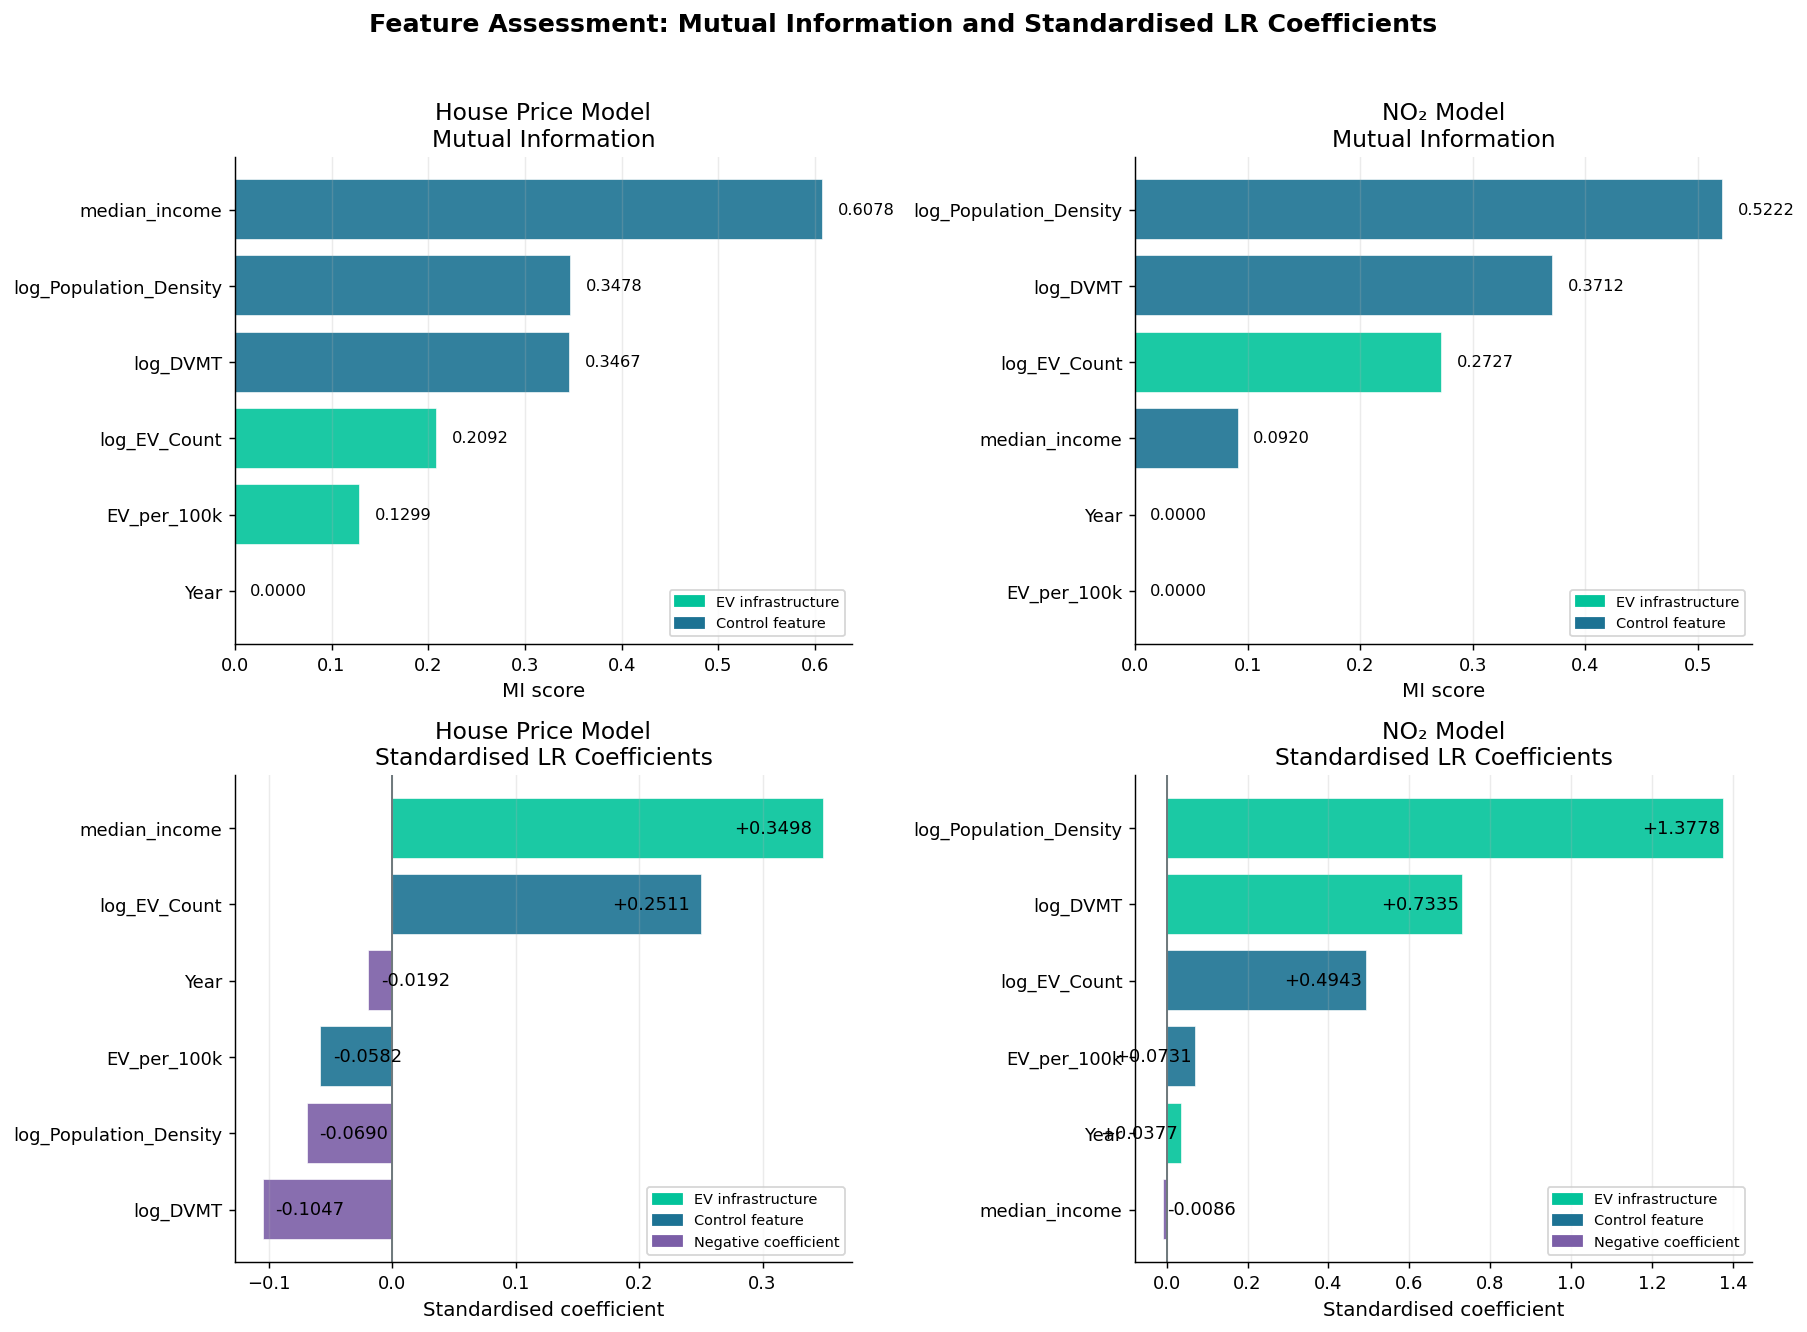

EV coefficient direction summary:
-------------------------------------------------------------------------------------

House Price Model — target: median house price
  log_EV_Count      : coefficient = +0.2511 → positive association with median house price
  EV_per_100k       : coefficient = -0.0582 → negative association with median house price

NO₂ Model — target: median NO₂
  log_EV_Count      : coefficient = +0.4943 → positive association with median NO₂
  EV_per_100k       : coefficient = +0.0731 → positive association with median NO₂


In [19]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches

# Feature selection/assessment is performed on the training set only.
#
# Mutual Information (MI):
# - Measures the univariate dependency between each feature and the target.
# - Can detect both linear and nonlinear relationships.
# - An estimated MI near 0 suggests little detectable information, but does not
#   prove statistical independence.
#
# Standardised Linear Regression coefficients:
# - Sign indicates the conditional direction of the relationship.
# - Magnitudes are comparable because all predictors are standardised.
#
# These results are used to rank and interpret the retained features,
# not to automatically remove control variables.

EV_FEATURES = ['log_EV_Count', 'EV_per_100k']

n_models = len(MODEL_CONFIGS)

fig, axes = plt.subplots(
    2,
    n_models,
    figsize=(7 * n_models, 10),
    squeeze=False
)

fig.suptitle(
    'Feature Assessment: Mutual Information and Standardised LR Coefficients',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

lr_models = {}
mi_results = {}
coef_results = {}

for col_i, (mname, cfg) in enumerate(MODEL_CONFIGS.items()):

    feats = cfg['features']
    target = cfg['target']

    # Use training data only
    tr = train_imputed[feats + [target]].dropna()

    X_train_fs = tr[feats]
    y_train_fs = tr[target]

    # ── Mutual Information ────────────────────────────────────────────────
    mi = mutual_info_regression(
        X_train_fs,
        y_train_fs,
        random_state=42
    )

    mi_s = pd.Series(mi, index=feats).sort_values()
    mi_results[mname] = mi_s

    ax_mi = axes[0, col_i]

    mi_colors = [
        GREEN if feature in EV_FEATURES else BLUE
        for feature in mi_s.index
    ]

    ax_mi.barh(
        mi_s.index,
        mi_s.values,
        color=mi_colors,
        edgecolor='white',
        alpha=0.9
    )

    mi_offset = max(mi_s.max() * 0.025, 0.002)

    for feature, value in mi_s.items():
        ax_mi.text(
            value + mi_offset,
            feature,
            f'{value:.4f}',
            va='center',
            fontsize=9
        )

    ax_mi.set_title(f'{mname}\nMutual Information')
    ax_mi.set_xlabel('MI score')
    ax_mi.grid(axis='x', alpha=0.25)

    ax_mi.legend(
            handles=[
                mpatches.Patch(color=GREEN, label='EV infrastructure'),
                mpatches.Patch(color=BLUE, label='Control feature')
            ],
            fontsize=8,
            loc='lower right'
        )

    # ── Standardised Linear Regression Coefficients ───────────────────────
    # Standardising X allows coefficient magnitudes to be compared.
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train_fs)

    lr = LinearRegression()
    lr.fit(X_scaled, y_train_fs)

    lr_models[mname] = {
        'model': lr,
        'scaler': scaler,
        'features': feats,
        'target': target
    }

    coef_s = pd.Series(lr.coef_, index=feats).sort_values()
    coef_results[mname] = coef_s

    ax_coef = axes[1, col_i]

    coef_colors = [
        BLUE if feature in EV_FEATURES
        else GREEN if value > 0
        else PURPLE
        for feature, value in coef_s.items()
    ]

    ax_coef.barh(
        coef_s.index,
        coef_s.values,
        color=coef_colors,
        edgecolor='white',
        alpha=0.9
    )

    ax_coef.axvline(0, color=GRAY, linewidth=1)

    coef_limit = max(abs(coef_s).max(), 1e-8)
    coef_offset = coef_limit * 0.035

    for feature, value in coef_s.items():
        x_position = (
            value + coef_offset
            if value >= 0
            else value - coef_offset
        )

    for i, value in coef_s.items():

        if value >= 0:
            ax_coef.text(
                value - 0.01,      # move inside the bar
                i,
                f"{value:+.4f}",
                ha="right",
                va="center",
                color="black",
                fontsize=10,
            )
        else:
            ax_coef.text(
                value + 0.01,      # move inside the negative bar
                i,
                f"{value:+.4f}",
                ha="left",
                va="center",
                color="black",
                fontsize=10,
            )

    ax_coef.set_title(f'{mname}\nStandardised LR Coefficients')
    ax_coef.set_xlabel('Standardised coefficient')
    ax_coef.grid(axis='x', alpha=0.25)

    ax_coef.legend(
            handles=[
                mpatches.Patch(color=GREEN, label='EV infrastructure'),
                mpatches.Patch(color=BLUE, label='Control feature'),
                mpatches.Patch(color=PURPLE, label='Negative coefficient')
            ],
            fontsize=8,
            loc='lower right',
        )



plt.tight_layout()
plt.show()


# ── EV coefficient direction summary ──────────────────────────────────────
print('EV coefficient direction summary:')
print('-' * 85)

for mname, coef_s in coef_results.items():

    target = MODEL_CONFIGS[mname]['target']
    outcome_name = (
        'median house price'
        if target == 'log_Price_Q50'
        else 'median NO₂'
    )

    print(f'\n{mname} — target: {outcome_name}')

    for ev_feature in EV_FEATURES:
        ev_coef = coef_s[ev_feature]

        if ev_coef > 0:
            direction = f'positive association with {outcome_name}'
        elif ev_coef < 0:
            direction = f'negative association with {outcome_name}'
        else:
            direction = f'no linear association with {outcome_name}'

        print(
            f'  {ev_feature:<18}: '
            f'coefficient = {ev_coef:+.4f} → {direction}'
        )

In [20]:
import statsmodels.api as sm

print("=" * 120)
print("OLS Feature Significance")
print("=" * 120)

ols_results = {}

for mname, cfg in MODEL_CONFIGS.items():

    feats = cfg["features"]
    target = cfg["target"]

    tr = train_imputed[feats + [target]].dropna()

    X = tr[feats]
    y = tr[target]

    # Standardize predictors so coefficients are comparable
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_scaled = pd.DataFrame(
        X_scaled,
        columns=feats,
        index=X.index
    )

    X_scaled = sm.add_constant(X_scaled)

    ols = sm.OLS(y, X_scaled).fit()

    ols_results[mname] = ols

    print(f"\n{'='*120}")
    print(mname)
    print(f"{'='*120}")

    results = pd.DataFrame({
        "Coefficient": ols.params,
        "Std.Err": ols.bse,
        "t": ols.tvalues,
        "P>|t|": ols.pvalues,
        "95% CI Lower": ols.conf_int()[0],
        "95% CI Upper": ols.conf_int()[1]
    })

    print(results.round(4))

    print(f"\nR²      : {ols.rsquared:.4f}")
    print(f"Adj. R² : {ols.rsquared_adj:.4f}")

OLS Feature Significance

House Price Model
                        Coefficient  Std.Err         t   P>|t|  95% CI Lower  \
const                       12.8318   0.0154  830.8792  0.0000       12.8014   
log_EV_Count                 0.2511   0.0382    6.5767  0.0000        0.1760   
EV_per_100k                 -0.0582   0.0231   -2.5212  0.0121       -0.1035   
log_DVMT                    -0.1047   0.0381   -2.7481  0.0063       -0.1797   
log_Population_Density      -0.0690   0.0222   -3.1055  0.0021       -0.1128   
median_income                0.3498   0.0181   19.3109  0.0000        0.3142   
Year                        -0.0192   0.0155   -1.2354  0.2175       -0.0498   

                        95% CI Upper  
const                        12.8622  
log_EV_Count                  0.3261  
EV_per_100k                  -0.0128  
log_DVMT                     -0.0298  
log_Population_Density       -0.0253  
median_income                 0.3855  
Year                          0.0114  

R²

---
# Train & Evaluate Models - LR & XGBOOST

### Evaluation strategy: GroupKFold cross-validation

Standard KFold would split rows randomly — the same county's 2023 and 2024 rows could end up in both train and validation, letting the model memorise county-level averages (county leakage).  
**GroupKFold** with groups=fips keeps all rows of the same county in the same fold — validation is always on counties the model has never seen within that fold.

In [21]:
# ============================================================================
# Train and compare Linear Regression and XGBoost for both prediction tasks
#
# Model 1: Predict log median house price
# Model 2: Predict median NO₂
#
# GroupKFold ensures that observations from the same county never appear in
# both the training and validation folds.
# ============================================================================

gkf = GroupKFold(n_splits=5)

PARAM_GRID = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.05, 0.10],
    'subsample': [0.7, 0.9],
}

all_results = {}

for mname, cfg in MODEL_CONFIGS.items():

    features = cfg['features']
    target = cfg['target']

    # Keep required variables only
    train_model = train_imputed[
        features + [target, 'fips']
    ].dropna()

    test_model = test_imputed[
        features + [target]
    ].dropna()

    X_train = train_model[features]
    y_train = train_model[target]

    X_test = test_model[features]
    y_test = test_model[target]

    groups = train_model['fips']

    # Group-aware validation splits
    cv_splits = list(
        gkf.split(
            X_train,
            y_train,
            groups=groups
        )
    )

    # ======================================================================
    # 1. Linear Regression baseline
    # ======================================================================

    lr_model = LinearRegression()

    lr_cv_scores = cross_val_score(
        estimator=lr_model,
        X=X_train,
        y=y_train,
        cv=cv_splits,
        scoring='r2',
        n_jobs=-1
    )

    # Fit on the entire training set after CV evaluation
    lr_model.fit(X_train, y_train)

    lr_train_pred = lr_model.predict(X_train)
    lr_test_pred = lr_model.predict(X_test)

    lr_metrics = {
        'Train R²': r2_score(y_train, lr_train_pred),
        'CV R²': lr_cv_scores.mean(),
        'CV std': lr_cv_scores.std(),
        'Test R²': r2_score(y_test, lr_test_pred),
        'Train MAE': mean_absolute_error(y_train, lr_train_pred),
        'Test MAE': mean_absolute_error(y_test, lr_test_pred),
        'Train RMSE': mean_squared_error(
            y_train,
            lr_train_pred
        ) ** 0.5,
        'Test RMSE': mean_squared_error(
            y_test,
            lr_test_pred
        ) ** 0.5,
    }

    # ======================================================================
    # 2. XGBoost with GroupKFold hyperparameter tuning
    # ======================================================================

    xgb_base = xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        verbosity=0,
        n_jobs=1
    )

    grid_search = GridSearchCV(
        estimator=xgb_base,
        param_grid=PARAM_GRID,
        scoring='r2',
        cv=cv_splits,
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)

    xgb_model = grid_search.best_estimator_

    xgb_train_pred = xgb_model.predict(X_train)
    xgb_test_pred = xgb_model.predict(X_test)

    xgb_metrics = {
        'Train R²': r2_score(y_train, xgb_train_pred),
        'CV R²': grid_search.best_score_,
        'CV std': grid_search.cv_results_['std_test_score'][
            grid_search.best_index_
        ],
        'Test R²': r2_score(y_test, xgb_test_pred),
        'Train MAE': mean_absolute_error(y_train, xgb_train_pred),
        'Test MAE': mean_absolute_error(y_test, xgb_test_pred),
        'Train RMSE': mean_squared_error(
            y_train,
            xgb_train_pred
        ) ** 0.5,
        'Test RMSE': mean_squared_error(
            y_test,
            xgb_test_pred
        ) ** 0.5,
    }

    # ======================================================================
    # Store results
    # ======================================================================

    all_results[mname] = {
        'config': cfg,
        'features': features,
        'target': target,

        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test,

        'groups': groups,
        'cv_splits': cv_splits,

        'lr_model': lr_model,
        'xgb_model': xgb_model,
        'grid_search': grid_search,

        'lr_train_pred': lr_train_pred,
        'lr_test_pred': lr_test_pred,
        'xgb_train_pred': xgb_train_pred,
        'xgb_test_pred': xgb_test_pred,

        'lr_metrics': lr_metrics,
        'xgb_metrics': xgb_metrics,

        'best_params': grid_search.best_params_,
    }

    # ======================================================================
    # Print model comparison
    # ======================================================================

    print('=' * 95)
    print(mname)
    print('=' * 95)

    print(f'Target: {target}')
    print(f'Inputs: {features}\n')

    print(
        f'LR  → '
        f'CV R² = {lr_metrics["CV R²"]:.3f} '
        f'± {lr_metrics["CV std"]:.3f} | '
        f'Test R² = {lr_metrics["Test R²"]:.3f} | '
        f'Test MAE = {lr_metrics["Test MAE"]:.3f}'
    )

    print(
        f'XGB → '
        f'CV R² = {xgb_metrics["CV R²"]:.3f} '
        f'± {xgb_metrics["CV std"]:.3f} | '
        f'Test R² = {xgb_metrics["Test R²"]:.3f} | '
        f'Test MAE = {xgb_metrics["Test MAE"]:.3f}'
    )

    print(f'\nBest XGBoost parameters: {grid_search.best_params_}')
    print()

House Price Model
Target: log_Price_Q50
Inputs: ['log_EV_Count', 'EV_per_100k', 'log_DVMT', 'log_Population_Density', 'median_income', 'Year']

LR  → CV R² = 0.627 ± 0.146 | Test R² = 0.742 | Test MAE = 0.164
XGB → CV R² = 0.675 ± 0.086 | Test R² = 0.668 | Test MAE = 0.204

Best XGBoost parameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.9}

NO₂ Model
Target: NO2_Q50
Inputs: ['log_EV_Count', 'EV_per_100k', 'log_DVMT', 'log_Population_Density', 'median_income', 'Year']

LR  → CV R² = 0.281 ± 0.041 | Test R² = 0.289 | Test MAE = 1.960
XGB → CV R² = 0.390 ± 0.061 | Test R² = 0.315 | Test MAE = 1.938

Best XGBoost parameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.7}



# LOFO

In [22]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import pandas as pd

# ============================================================
# Configuration
# ============================================================

FEATURES = [
    'log_EV_Count',
    'EV_per_100k',
    'log_DVMT',
    'log_Population_Density',
    'median_income',
    'Year'
]

TARGETS = {
    "House Price": "log_Price_Q50",
    "NO2": "NO2_Q50"
}

GROUPS = df["fips"]      # County groups
cv = GroupKFold(n_splits=5)

# ============================================================
# Final XGBoost parameters
# ============================================================

XGB_PARAMS = {
    "House Price": {
        "learning_rate": 0.05,
        "max_depth": 2,
        "n_estimators": 200,
        "subsample": 0.9,
        "random_state": 42
    },
    "NO2": {
        "learning_rate": 0.05,
        "max_depth": 2,
        "n_estimators": 100,
        "subsample": 0.7,
        "random_state": 42
    }
}

# ============================================================
# LOFO Function
# ============================================================

def lofo_analysis(model, X, y, groups):

    baseline = cross_val_score(
        model,
        X,
        y,
        cv=cv.split(X, y, groups),
        scoring="r2",
        n_jobs=-1
    ).mean()

    results = []

    for feature in X.columns:

        X_drop = X.drop(columns=[feature])

        score = cross_val_score(
            model,
            X_drop,
            y,
            cv=cv.split(X_drop, y, groups),
            scoring="r2",
            n_jobs=-1
        ).mean()

        results.append({
            "Removed Feature": feature,
            "CV R²": score,
            "ΔR²": baseline - score
        })

    results = pd.DataFrame(results)
    results = results.sort_values("ΔR²", ascending=False)

    return baseline, results

# ============================================================
# Run LOFO
# ============================================================

for task, target in TARGETS.items():

    print("=" * 80)
    print(task)
    print("=" * 80)

    X = df[FEATURES]
    y = df[target]

    # ---------------- LR ----------------

    lr = LinearRegression()

    baseline_lr, lofo_lr = lofo_analysis(
        lr,
        X,
        y,
        GROUPS
    )

    print(f"\nLinear Regression baseline CV R² = {baseline_lr:.3f}")
    print(lofo_lr)

    # ---------------- XGB ----------------

    xgb = XGBRegressor(
        **XGB_PARAMS[task]
    )

    baseline_xgb, lofo_xgb = lofo_analysis(
        xgb,
        X,
        y,
        GROUPS
    )

    print(f"\nXGBoost baseline CV R² = {baseline_xgb:.3f}")
    print(lofo_xgb)

    print("\n")

House Price

Linear Regression baseline CV R² = 0.636
          Removed Feature     CV R²       ΔR²
4           median_income  0.263341  0.373146
0            log_EV_Count  0.602503  0.033984
3  log_Population_Density  0.628077  0.008410
2                log_DVMT  0.633635  0.002852
1             EV_per_100k  0.634721  0.001767
5                    Year  0.636246  0.000242

XGBoost baseline CV R² = 0.669
          Removed Feature     CV R²       ΔR²
4           median_income  0.147249  0.521671
3  log_Population_Density  0.630238  0.038682
1             EV_per_100k  0.664361  0.004559
0            log_EV_Count  0.667904  0.001016
5                    Year  0.669649 -0.000729
2                log_DVMT  0.676242 -0.007322


NO2

Linear Regression baseline CV R² = 0.322
          Removed Feature     CV R²       ΔR²
3  log_Population_Density  0.249211  0.073130
2                log_DVMT  0.318944  0.003397
5                    Year  0.320750  0.001591
1             EV_per_100k  0.323198 -0

# REF

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import RFECV
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor


# ============================================================
# Configuration
# ============================================================

FEATURES = [
    "log_EV_Count",
    "EV_per_100k",
    "log_DVMT",
    "log_Population_Density",
    "median_income",
    "Year"
]

TARGETS = {
    "House Price": "log_Price_Q50",
    "NO2": "NO2_Q50"
}

XGB_PARAMS = {
    "House Price": {
        "learning_rate": 0.05,
        "max_depth": 2,
        "n_estimators": 200,
        "subsample": 0.9,
        "random_state": 42,
        "n_jobs": 1
    },
    "NO2": {
        "learning_rate": 0.05,
        "max_depth": 2,
        "n_estimators": 100,
        "subsample": 0.7,
        "random_state": 42,
        "n_jobs": 1
    }
}

group_cv = GroupKFold(n_splits=5)


# ============================================================
# RFECV function
# ============================================================

def run_rfecv(model, importance_getter, X, y, groups):
    """
    Runs recursive feature elimination with GroupKFold CV.

    Returns:
        fitted RFECV object
        feature-ranking DataFrame
        CV-performance DataFrame
    """

    selector = RFECV(
        estimator=model,
        step=1,
        min_features_to_select=1,
        cv=group_cv,
        scoring="r2",
        importance_getter=importance_getter,
        n_jobs=-1
    )

    selector.fit(X, y, groups=groups)

    ranking_df = pd.DataFrame({
        "Feature": X.columns,
        "Selected": selector.support_,
        "Ranking": selector.ranking_
    }).sort_values(
        by=["Selected", "Ranking"],
        ascending=[False, True]
    )

    cv_results_df = pd.DataFrame({
        "Number of Features": selector.cv_results_["n_features"],
        "Mean CV R²": selector.cv_results_["mean_test_score"],
        "Std CV R²": selector.cv_results_["std_test_score"]
    }).sort_values("Number of Features")

    return selector, ranking_df, cv_results_df


# ============================================================
# Use training data only
# ============================================================

# Replace train_df with the name of your training DataFrame.
# If you currently have X_train, y_train and groups_train separately,
# use those directly instead.

data_for_selection = train_df

X_train_fs = data_for_selection[FEATURES]
groups_train_fs = data_for_selection["fips"]


# Store all results
all_results = {}


# ============================================================
# Run RFECV for each target
# ============================================================

for task_name, target_column in TARGETS.items():

    y_train_fs = data_for_selection[target_column]

    print("\n" + "=" * 90)
    print(task_name)
    print("=" * 90)

    all_results[task_name] = {}

    # --------------------------------------------------------
    # Linear Regression
    # Standardisation occurs separately inside every CV fold.
    # --------------------------------------------------------

    lr_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    lr_selector, lr_ranking, lr_cv_results = run_rfecv(
        model=lr_pipeline,
        importance_getter="named_steps.model.coef_",
        X=X_train_fs,
        y=y_train_fs,
        groups=groups_train_fs
    )

    all_results[task_name]["Linear Regression"] = {
        "selector": lr_selector,
        "ranking": lr_ranking,
        "cv_results": lr_cv_results
    }

    print("\nLinear Regression")
    print(f"Optimal number of features: {lr_selector.n_features_}")
    print(
        "Selected features:",
        X_train_fs.columns[lr_selector.support_].tolist()
    )
    print("\nFeature ranking:")
    print(lr_ranking.to_string(index=False))
    print("\nCV results:")
    print(lr_cv_results.to_string(index=False))

    # --------------------------------------------------------
    # XGBoost
    # --------------------------------------------------------

    xgb_model = XGBRegressor(**XGB_PARAMS[task_name])

    xgb_selector, xgb_ranking, xgb_cv_results = run_rfecv(
        model=xgb_model,
        importance_getter="feature_importances_",
        X=X_train_fs,
        y=y_train_fs,
        groups=groups_train_fs
    )

    all_results[task_name]["XGBoost"] = {
        "selector": xgb_selector,
        "ranking": xgb_ranking,
        "cv_results": xgb_cv_results
    }

    print("\nXGBoost")
    print(f"Optimal number of features: {xgb_selector.n_features_}")
    print(
        "Selected features:",
        X_train_fs.columns[xgb_selector.support_].tolist()
    )
    print("\nFeature ranking:")
    print(xgb_ranking.to_string(index=False))
    print("\nCV results:")
    print(xgb_cv_results.to_string(index=False))


House Price

Linear Regression
Optimal number of features: 6
Selected features: ['log_EV_Count', 'EV_per_100k', 'log_DVMT', 'log_Population_Density', 'median_income', 'Year']

Feature ranking:
               Feature  Selected  Ranking
          log_EV_Count      True        1
           EV_per_100k      True        1
              log_DVMT      True        1
log_Population_Density      True        1
         median_income      True        1
                  Year      True        1

CV results:
 Number of Features  Mean CV R²  Std CV R²
                  1    0.583295   0.121941
                  2    0.615831   0.140901
                  3    0.615944   0.146579
                  4    0.614790   0.152719
                  5    0.626724   0.143627
                  6    0.627042   0.145744

XGBoost
Optimal number of features: 5
Selected features: ['log_EV_Count', 'EV_per_100k', 'log_DVMT', 'log_Population_Density', 'median_income']

Feature ranking:
               Feature  Selected  R

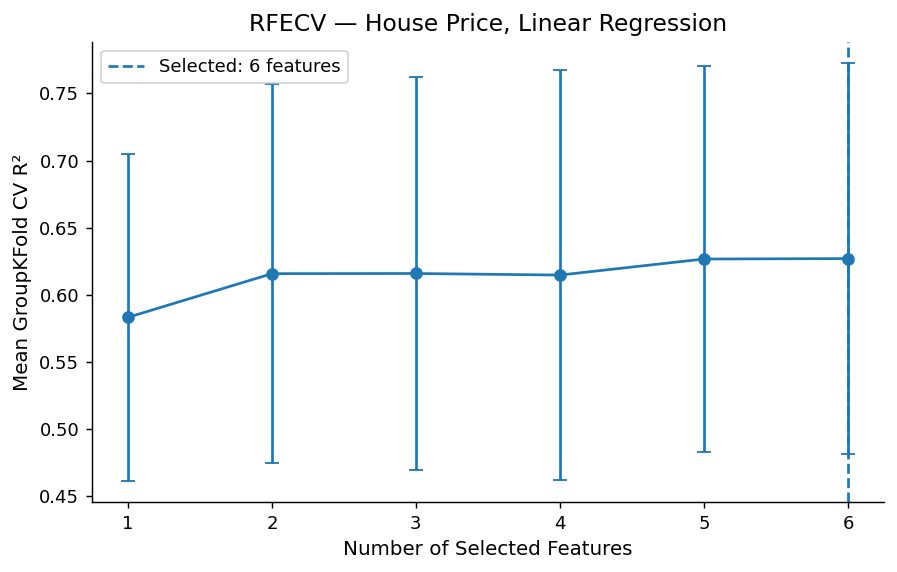

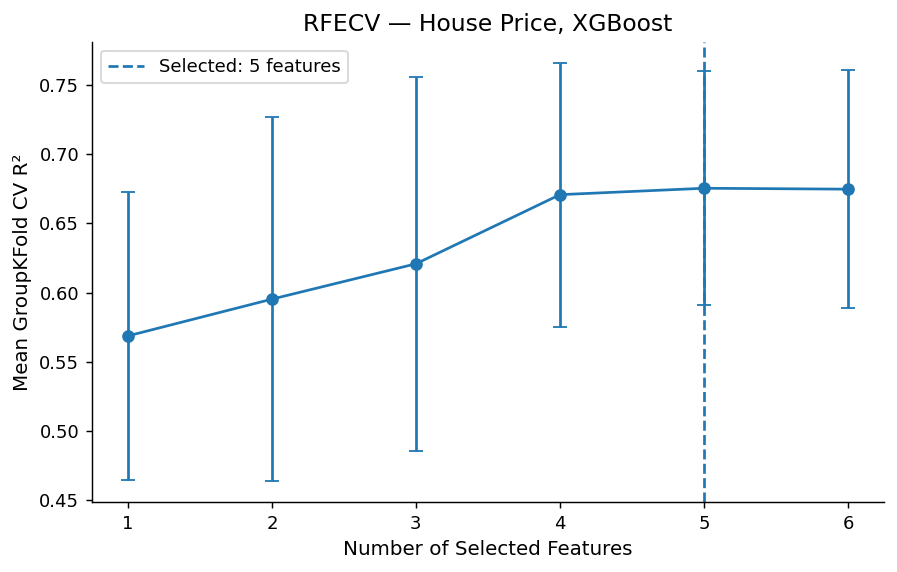

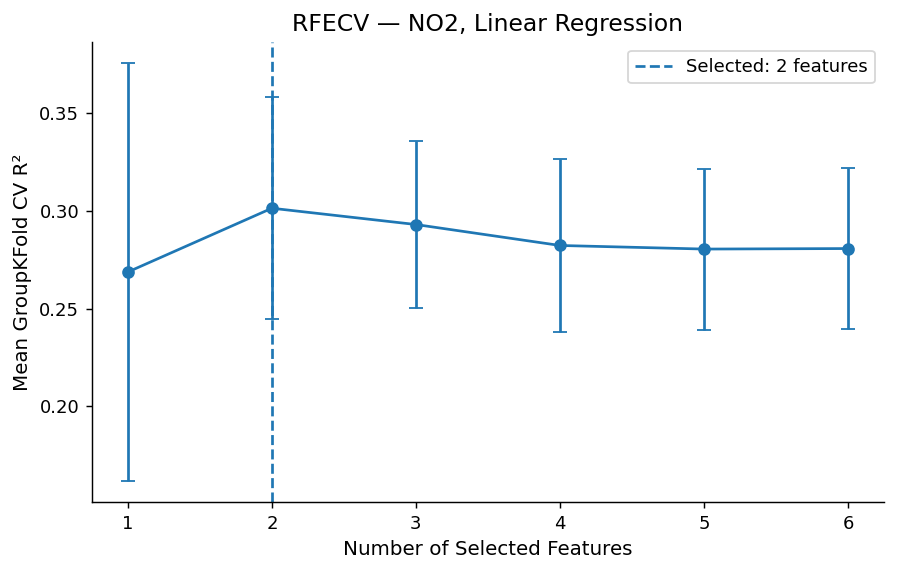

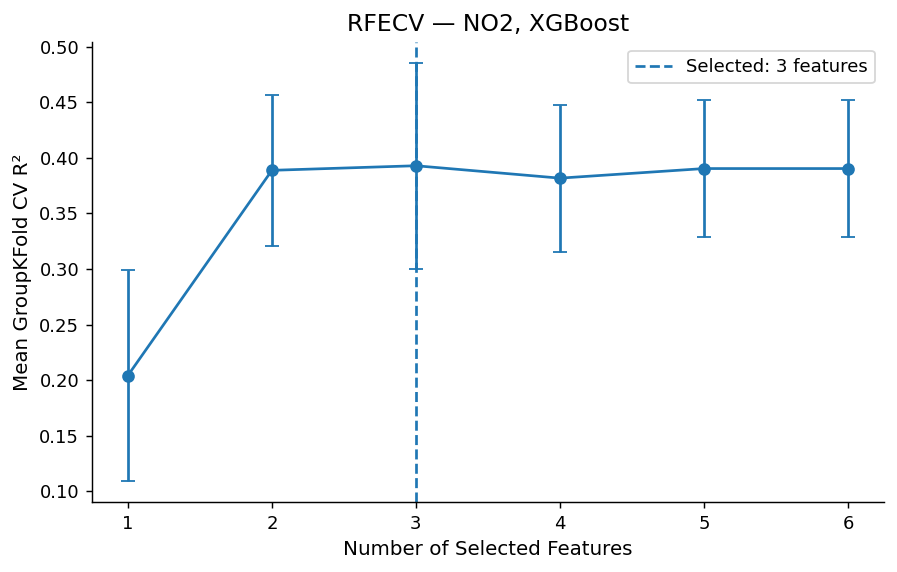

In [24]:
for task_name, model_results in all_results.items():

    for model_name, result in model_results.items():

        cv_df = result["cv_results"]

        plt.figure(figsize=(7, 4.5))

        plt.errorbar(
            cv_df["Number of Features"],
            cv_df["Mean CV R²"],
            yerr=cv_df["Std CV R²"],
            marker="o",
            capsize=4
        )

        optimal_n = result["selector"].n_features_

        plt.axvline(
            optimal_n,
            linestyle="--",
            label=f"Selected: {optimal_n} features"
        )

        plt.xlabel("Number of Selected Features")
        plt.ylabel("Mean GroupKFold CV R²")
        plt.title(f"RFECV — {task_name}, {model_name}")
        plt.xticks(cv_df["Number of Features"])
        plt.legend()
        plt.tight_layout()
        plt.show()

# Evaluate Models: Linear Regression and XGBoost

In [27]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor


# ============================================================
# Final feature sets
# ============================================================

HOUSE_PRICE_FEATURES = [
    "log_EV_Count",
    "EV_per_100k",
    "log_DVMT",
    "log_Population_Density",
    "median_income",
    "Year"
]

NO2_FEATURES = [
    "log_EV_Count",
    "log_DVMT",
    "log_Population_Density",
    "Year"
]


# ============================================================
# Task configuration
# Change df_final if your final DataFrame has another name
# ============================================================

task_config = {
    "House Price": {
        "target": "log_Price_Q50",
        "features": HOUSE_PRICE_FEATURES
    },
    "NO2": {
        "target": "NO2_Q50",
        "features": NO2_FEATURES
    }
}


# ============================================================
# Train/test split
# Train: 2023-2024
# Test: 2025
# ============================================================

train_df = df[df["Year"].isin([2023, 2024])].copy()
test_df = df[df["Year"] == 2025].copy()

# Group counties during cross-validation
# Change "fips" if your county identifier has a different name
train_groups = train_df["fips"]


# ============================================================
# Models and hyperparameter grids
# ============================================================

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "n_estimators": [100, 200, 300],
    "subsample": [0.7, 0.9, 1.0]
}

group_cv = GroupKFold(n_splits=5)


# ============================================================
# Train and evaluate both prediction tasks
# ============================================================

all_results = {}

for task_name, config in task_config.items():

    features = config["features"]
    target = config["target"]

    X_train = train_df[features].copy()
    y_train = train_df[target].copy()

    X_test = test_df[features].copy()
    y_test = test_df[target].copy()

    # --------------------------------------------------------
    # Linear Regression
    # --------------------------------------------------------

    lr_cv_scores = cross_val_score(
        lr_pipeline,
        X_train,
        y_train,
        groups=train_groups,
        cv=group_cv,
        scoring="r2",
        n_jobs=-1
    )

    lr_pipeline.fit(X_train, y_train)
    lr_predictions = lr_pipeline.predict(X_test)

    lr_metrics = {
        "CV R²": lr_cv_scores.mean(),
        "CV std": lr_cv_scores.std(),
        "Test R²": r2_score(y_test, lr_predictions),
        "Test MAE": mean_absolute_error(y_test, lr_predictions),
        "Test RMSE": np.sqrt(
            mean_squared_error(y_test, lr_predictions)
        )
    }

    # --------------------------------------------------------
    # XGBoost with GroupKFold GridSearchCV
    # --------------------------------------------------------

    xgb_grid = GridSearchCV(
        estimator=xgb_model,
        param_grid=xgb_param_grid,
        scoring="r2",
        cv=group_cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    xgb_grid.fit(
        X_train,
        y_train,
        groups=train_groups
    )

    best_xgb = xgb_grid.best_estimator_

    # Cross-validation scores of the selected XGBoost model
    xgb_cv_scores = cross_val_score(
        best_xgb,
        X_train,
        y_train,
        groups=train_groups,
        cv=group_cv,
        scoring="r2",
        n_jobs=-1
    )

    xgb_predictions = best_xgb.predict(X_test)

    xgb_metrics = {
        "CV R²": xgb_cv_scores.mean(),
        "CV std": xgb_cv_scores.std(),
        "Test R²": r2_score(y_test, xgb_predictions),
        "Test MAE": mean_absolute_error(y_test, xgb_predictions),
        "Test RMSE": np.sqrt(
            mean_squared_error(y_test, xgb_predictions)
        )
    }

    # --------------------------------------------------------
    # Save results in the structure expected by your plots
    # --------------------------------------------------------

    all_results[task_name] = {
        "features": features,
        "target": target,
        "lr_model": lr_pipeline,
        "xgb_model": best_xgb,
        "lr_metrics": lr_metrics,
        "xgb_metrics": xgb_metrics,
        "xgb_best_params": xgb_grid.best_params_,
        "y_test": y_test,
        "lr_predictions": lr_predictions,
        "xgb_predictions": xgb_predictions
    }


# ============================================================
# Print results
# ============================================================

for task_name, result in all_results.items():

    print("=" * 70)
    print(task_name)
    print("=" * 70)

    print("\nFeatures:")
    print(result["features"])

    print("\nLinear Regression:")
    for metric, value in result["lr_metrics"].items():
        print(f"{metric}: {value:.4f}")

    print("\nXGBoost:")
    for metric, value in result["xgb_metrics"].items():
        print(f"{metric}: {value:.4f}")

    print("\nBest XGBoost parameters:")
    print(result["xgb_best_params"])
    print()

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits
House Price

Features:
['log_EV_Count', 'EV_per_100k', 'log_DVMT', 'log_Population_Density', 'median_income', 'Year']

Linear Regression:
CV R²: 0.6658
CV std: 0.0741
Test R²: 0.6116
Test MAE: 0.2072
Test RMSE: 0.2836

XGBoost:
CV R²: 0.7166
CV std: 0.0445
Test R²: 0.8719
Test MAE: 0.1109
Test RMSE: 0.1629

Best XGBoost parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.9}

NO2

Features:
['log_EV_Count', 'log_DVMT', 'log_Population_Density', 'Year']

Linear Regression:
CV R²: 0.2998
CV std: 0.0952
Test R²: 0.3934
Test MAE: 2.1157
Test RMSE: 2.7019

XGBoost:
CV R²: 0.3831
CV std: 0.0754
Test R²: 0.5931
Test MAE: 1.7362
Test RMSE: 2.2128

Best XGBoost parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.9}



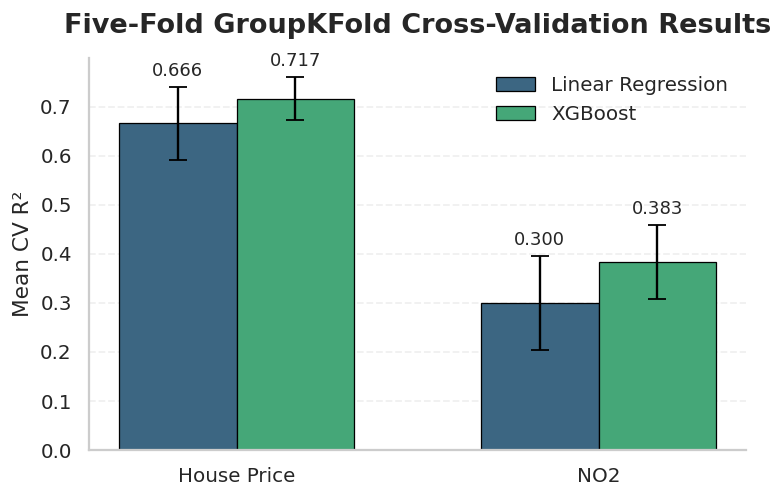

In [28]:
# ============================================================================
# Cross-validation R² comparison
# Mean ± standard deviation across 5 GroupKFold folds
# ============================================================================

cv_rows = []

for task_name, res in all_results.items():

    cv_rows.extend([
        {
            "Prediction Task": task_name,
            "Model": "Linear Regression",
            "Mean CV R²": res["lr_metrics"]["CV R²"],
            "CV Std": res["lr_metrics"]["CV std"]
        },
        {
            "Prediction Task": task_name,
            "Model": "XGBoost",
            "Mean CV R²": res["xgb_metrics"]["CV R²"],
            "CV Std": res["xgb_metrics"]["CV std"]
        }
    ])

cv_df = pd.DataFrame(cv_rows)

sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    data=cv_df,
    x="Prediction Task",
    y="Mean CV R²",
    hue="Model",
    palette="viridis",
    width=0.65,
    edgecolor="black",
    linewidth=0.7,
    errorbar=None,
    ax=ax
)

# Add the actual GroupKFold standard deviations as error bars
models = ["Linear Regression", "XGBoost"]

for container, model_name in zip(ax.containers, models):

    model_data = (
        cv_df[cv_df["Model"] == model_name]
        .set_index("Prediction Task")
    )

    for bar in container:

        task_name = ax.get_xticklabels()[
            int(round(bar.get_x() + bar.get_width() / 2))
        ].get_text()

        mean_value = bar.get_height()
        std_value = model_data.loc[task_name, "CV Std"]

        ax.errorbar(
            x=bar.get_x() + bar.get_width() / 2,
            y=mean_value,
            yerr=std_value,
            fmt="none",
            color="black",
            capsize=5,
            linewidth=1.3
        )

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            mean_value + std_value + 0.015,
            f"{mean_value:.3f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

ax.set_title(
    "Five-Fold GroupKFold Cross-Validation Results",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("")
ax.set_ylabel("Mean CV R²")

ax.legend(
    title="",
    frameon=False
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# Performance Chart of All Models

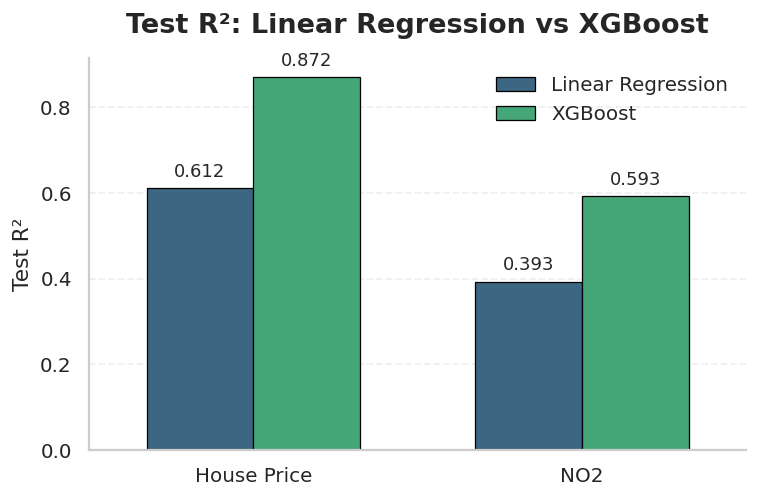

In [29]:
sns.set_theme(style="whitegrid", context="notebook")

# Build plotting DataFrame
plot_rows = []

for task_name, result in all_results.items():

    for model_name, metrics_key in [
        ("Linear Regression", "lr_metrics"),
        ("XGBoost", "xgb_metrics")
    ]:
        metrics = result[metrics_key]

        plot_rows.extend([
            {
                "Prediction Task": task_name,
                "Model": model_name,
                "Metric": "Test R²",
                "Value": metrics["Test R²"]
            },
            {
                "Prediction Task": task_name,
                "Model": model_name,
                "Metric": "Test MAE",
                "Value": metrics["Test MAE"]
            },
            {
                "Prediction Task": task_name,
                "Model": model_name,
                "Metric": "Test RMSE",
                "Value": metrics["Test RMSE"]
            }
        ])

plot_df = pd.DataFrame(plot_rows)


r2_df = plot_df[plot_df["Metric"] == "Test R²"]

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=r2_df,
    x="Prediction Task",
    y="Value",
    hue="Model",
    palette="viridis",
    width=0.65,
    edgecolor="black",
    linewidth=0.7
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=4,
        fontsize=10
    )

ax.set_title(
    "Test R²: Linear Regression vs XGBoost",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("")
ax.set_ylabel("Test R²")
ax.legend(title="", frameon=False)

ax.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

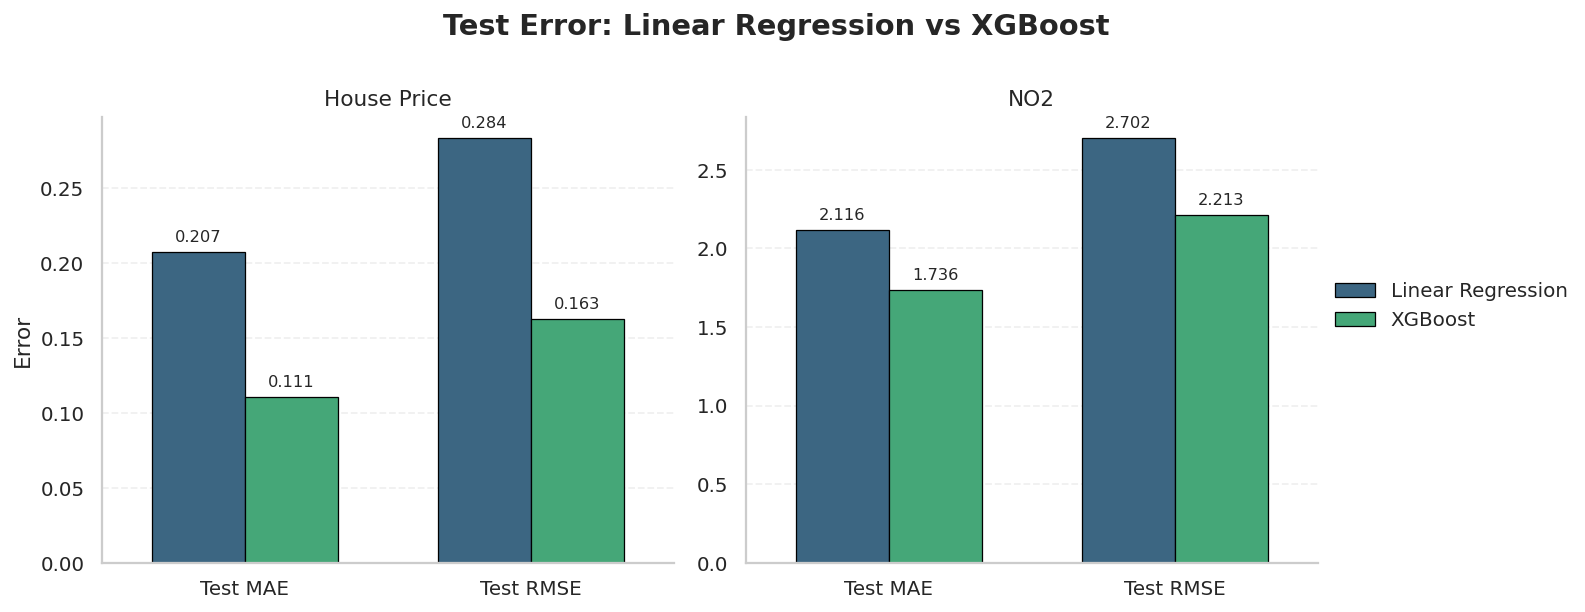

In [30]:
error_df = plot_df[
    plot_df["Metric"].isin(["Test MAE", "Test RMSE"])
]

g = sns.catplot(
    data=error_df,
    kind="bar",
    x="Metric",
    y="Value",
    hue="Model",
    col="Prediction Task",
    palette="viridis",
    width=0.65,
    edgecolor="black",
    linewidth=0.7,
    height=5,
    aspect=1.05,
    sharey=False
)

g.set_axis_labels("", "Error")
g.set_titles("{col_name}")

g.fig.subplots_adjust(top=0.82)
g.fig.suptitle(
    "Test Error: Linear Regression vs XGBoost",
    fontsize=16,
    fontweight="bold"
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            padding=4,
            fontsize=9
        )

    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

g.legend.set_title("")

plt.show()

# Predicted vs Actual on Test Set

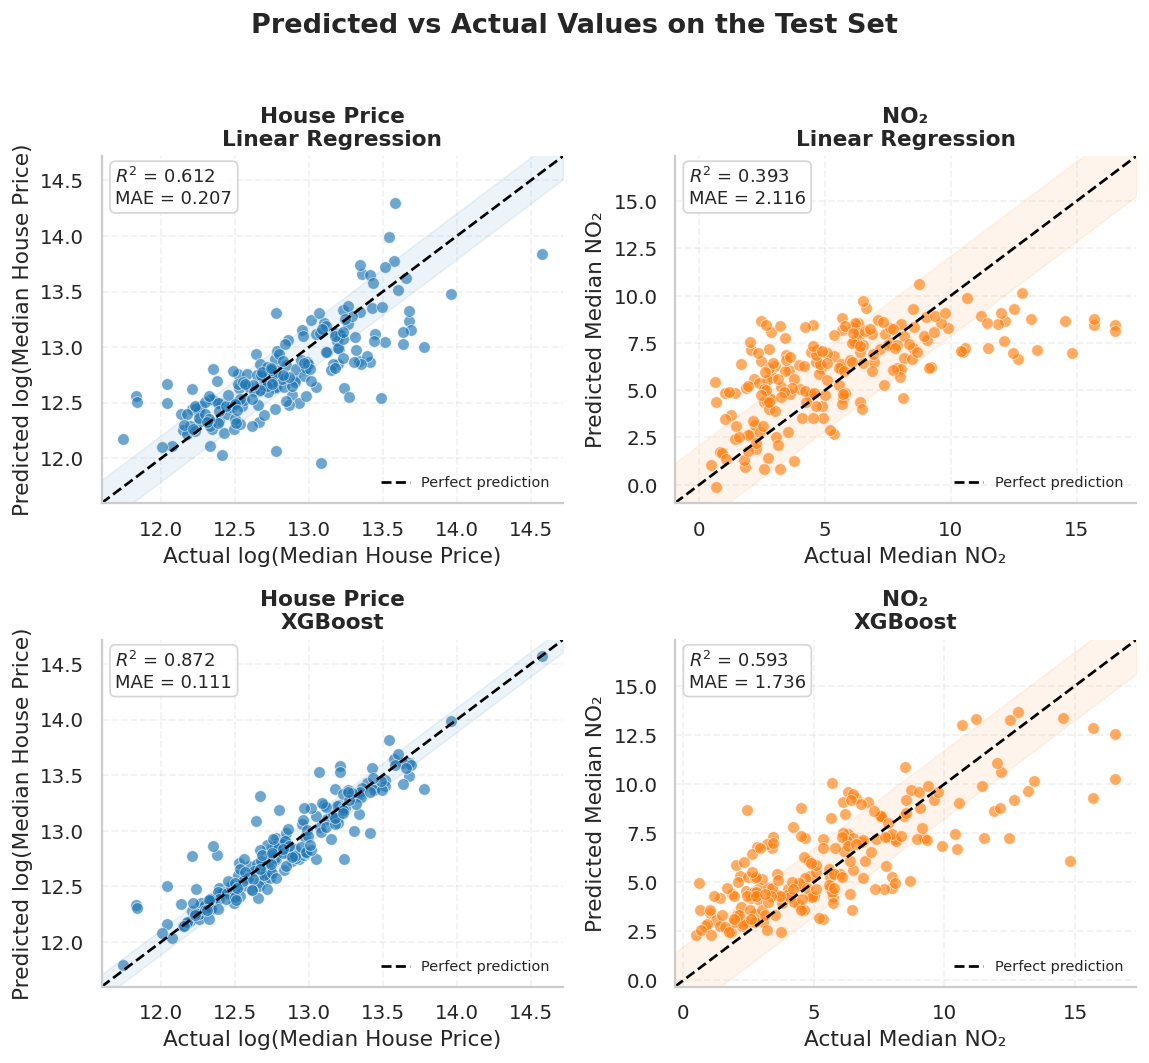

In [32]:
# ============================================================================
# Predicted vs Actual on the Test Set
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score, mean_absolute_error


sns.set_theme(style="whitegrid", context="notebook")

n_tasks = len(all_results)

fig, axes = plt.subplots(
    2,
    n_tasks,
    figsize=(4.5 * n_tasks, 8)
)

# Ensure axes is always a 2D array
if n_tasks == 1:
    axes = np.array(axes).reshape(2, 1)

fig.suptitle(
    "Predicted vs Actual Values on the Test Set",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

# One colour for each prediction task
task_colors = {
    "House Price": "tab:blue",
    "NO2": "tab:orange",
    "NO₂": "tab:orange"
}

for col, (task_name, res) in enumerate(all_results.items()):

    color = task_colors.get(task_name, "tab:blue")

    y_test = np.asarray(res["y_test"])

    xlabel = (
        "log(Median House Price)"
        if "Price" in task_name
        else "Median NO₂"
    )

    models = [
        (
            np.asarray(res["lr_predictions"]),
            "Linear Regression",
            res["lr_metrics"]
        ),
        (
            np.asarray(res["xgb_predictions"]),
            "XGBoost",
            res["xgb_metrics"]
        )
    ]

    for row, (y_pred, model_name, metrics) in enumerate(models):

        ax = axes[row, col]

        r2 = metrics["Test R²"]
        mae = metrics["Test MAE"]

        ax.scatter(
            y_test,
            y_pred,
            color=color,
            alpha=0.65,
            s=42,
            edgecolor="white",
            linewidth=0.5
        )

        # Shared axis limits for actual and predicted values
        lo = min(y_test.min(), y_pred.min())
        hi = max(y_test.max(), y_pred.max())

        value_range = hi - lo
        pad = 0.05 * value_range if value_range > 0 else 0.1

        lo -= pad
        hi += pad

        # Perfect-prediction reference line
        ax.plot(
            [lo, hi],
            [lo, hi],
            linestyle="--",
            color="black",
            linewidth=1.5,
            label="Perfect prediction"
        )

        # Approximate MAE band around the perfect-prediction line
        ax.fill_between(
            [lo, hi],
            [lo - mae, hi - mae],
            [lo + mae, hi + mae],
            color=color,
            alpha=0.08
        )

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

        display_task_name = (
            "NO₂"
            if task_name in ["NO2", "NO₂"]
            else task_name
        )

        ax.set_title(
            f"{display_task_name}\n{model_name}",
            fontsize=12,
            fontweight="bold"
        )

        ax.text(
            0.03,
            0.97,
            f"$R^2$ = {r2:.3f}\nMAE = {mae:.3f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            bbox={
                "facecolor": "white",
                "alpha": 0.9,
                "edgecolor": "lightgray",
                "boxstyle": "round,pad=0.3"
            }
        )

        ax.set_xlabel(f"Actual {xlabel}")
        ax.set_ylabel(f"Predicted {xlabel}")

        ax.grid(
            linestyle="--",
            alpha=0.25
        )

        sns.despine(ax=ax)

        ax.legend(
            frameon=False,
            fontsize=8,
            loc="lower right"
        )

plt.tight_layout()
plt.show()

---
# SHAP Feature Importance



In [34]:
# ============================================================================
# SHAP analysis for the XGBoost models
# ============================================================================

import shap
import numpy as np
import pandas as pd

shap_results = {}

for task_name, res in all_results.items():

    features = res["features"]

    X_train_df = train_df[features].copy()
    X_test_df = test_df[features].copy()

    xgb_model = res["xgb_model"]

    # SHAP explainer
    explainer = shap.TreeExplainer(xgb_model)

    shap_train = explainer(X_train_df)
    shap_test = explainer(X_test_df)

    # Global feature importance
    mean_abs_shap = np.abs(shap_train.values).mean(axis=0)

    importance = (
        pd.Series(mean_abs_shap, index=features)
        .sort_values(ascending=False)
    )

    shap_results[task_name] = {
        "explainer": explainer,
        "shap_train": shap_train,
        "shap_test": shap_test,
        "X_train_df": X_train_df,
        "X_test_df": X_test_df,
        "importance": importance
    }

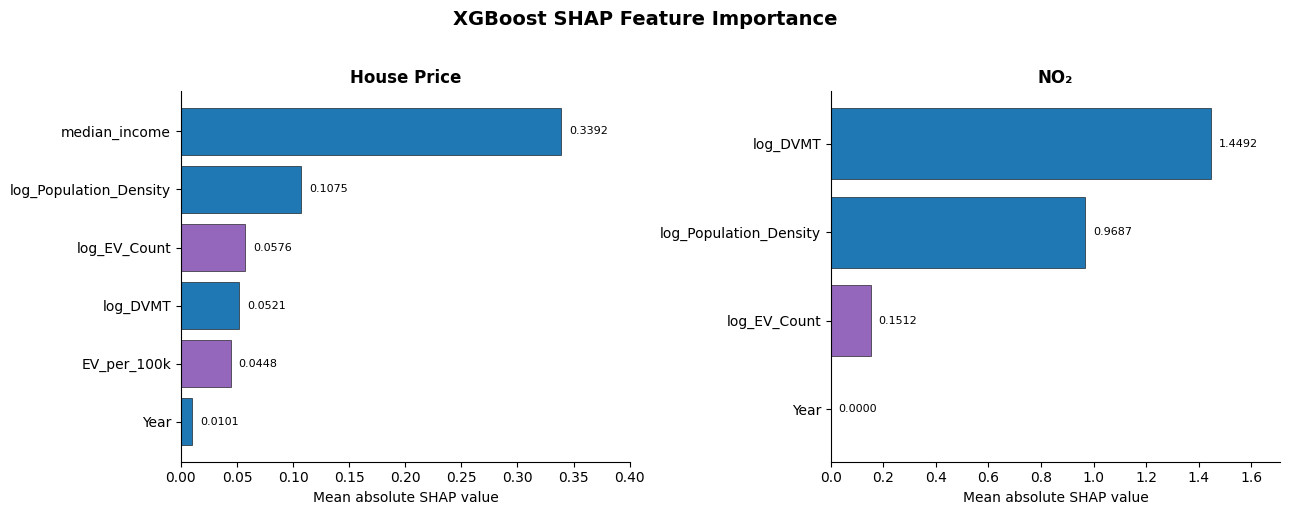

In [44]:
# ============================================================================
# XGBoost SHAP feature importance: mean absolute SHAP value
# ============================================================================

import matplotlib.pyplot as plt
import pandas as pd

# Reset any previously activated Seaborn or Matplotlib style
plt.style.use("default")

# EV-related predictors
ev_features = {"log_EV_Count", "EV_per_100k"}

n_tasks = len(shap_results)

fig, axes = plt.subplots(
    1,
    n_tasks,
    figsize=(6.5 * n_tasks, 5),
    squeeze=False
)

axes = axes.flatten()

for ax, (task_name, result) in zip(axes, shap_results.items()):

    # Sort in ascending order so the most important feature appears at the top
    importance = result["importance"].sort_values()

    plot_df = pd.DataFrame({
        "Feature": importance.index,
        "Mean absolute SHAP value": importance.values
    })

    # Highlight EV-related features
    bar_colors = [
        "tab:purple" if feature in ev_features else "tab:blue"
        for feature in plot_df["Feature"]
    ]

    bars = ax.barh(
        plot_df["Feature"],
        plot_df["Mean absolute SHAP value"],
        color=bar_colors,
        edgecolor="black",
        linewidth=0.4
    )

    max_importance = plot_df["Mean absolute SHAP value"].max()

    # Add importance values beside the bars
    for bar, value in zip(
        bars,
        plot_df["Mean absolute SHAP value"]
    ):
        ax.text(
            value + max_importance * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va="center",
            fontsize=8
        )

    display_task_name = (
        "NO₂" if task_name in ["NO2", "NO₂"] else task_name
    )

    ax.set_title(
        display_task_name,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("Mean absolute SHAP value")
    ax.set_ylabel("")

    # Remove all grid lines
    ax.grid(False)
    ax.xaxis.grid(False)
    ax.yaxis.grid(False)

    # Remove unnecessary borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Leave room for value labels
    ax.set_xlim(
        0,
        max_importance * 1.18
    )

# Remove unused axes
for ax in axes[len(shap_results):]:
    ax.remove()

fig.suptitle(
    "XGBoost SHAP Feature Importance",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

# Save for Overleaf
plt.savefig(
    "shap_feature_importance.pdf",
    bbox_inches="tight"
)

plt.show()

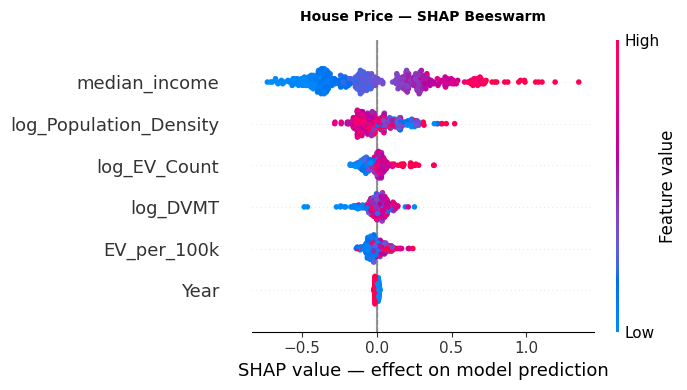

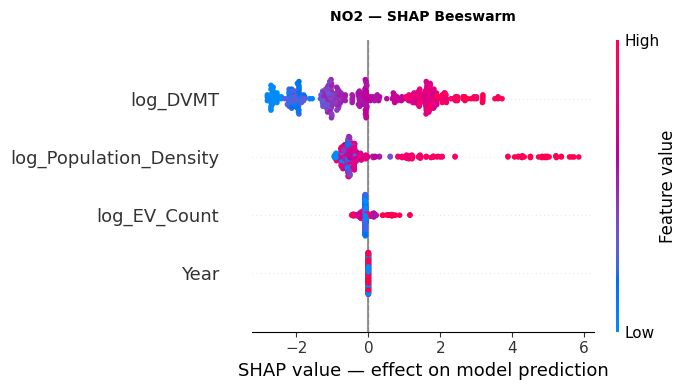

In [45]:
# ============================================================================
# SHAP beeswarm plots
# ============================================================================

# Each dot represents one county-year observation.
#
# Colour:
# Red  = high feature value
# Blue = low feature value
#
# Horizontal position:
# Right = increases the model prediction
# Left  = decreases the model prediction

for task_name, result in shap_results.items():

    plt.figure(figsize=(7, 4))

    shap.plots.beeswarm(
        result["shap_train"],
        max_display=len(result["importance"]),
        show=False,
        plot_size=None
    )

    ax = plt.gca()

    ax.axvline(
        0,
        color="grey",
        linewidth=1,
        linestyle="--",
        alpha=0.6
    )

    ax.set_title(
        f"{task_name} — SHAP Beeswarm",
        fontsize=10,
        fontweight="bold",
        pad=14
    )

    ax.set_xlabel("SHAP value — effect on model prediction")

    plt.tight_layout()
    plt.show()

# SHAP Waterfall

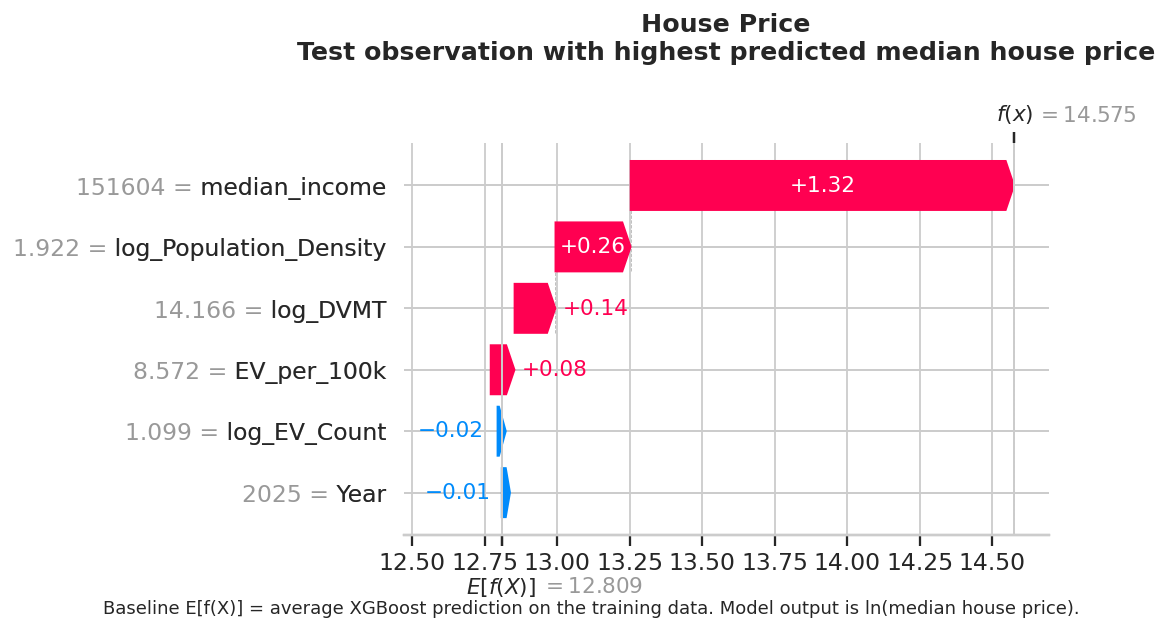

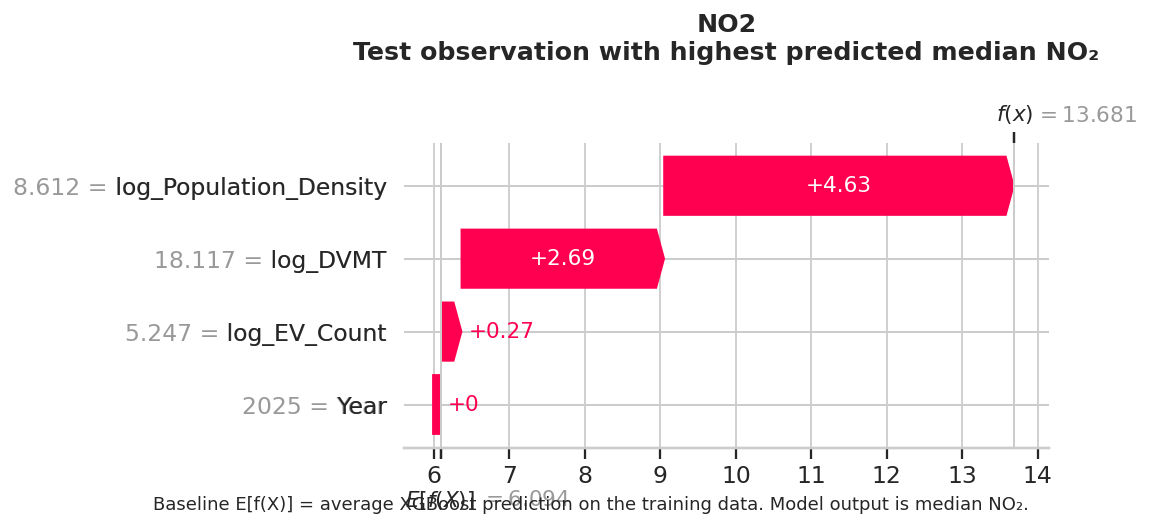

In [37]:
# ============================================================================
# SHAP waterfall plots — one separate figure per task
# ============================================================================

for task_name, sr in shap_results.items():

    # Reconstruct each test prediction:
    # prediction = baseline + sum of SHAP contributions
    shap_predictions = (
        np.asarray(sr["shap_test"].base_values).reshape(-1)
        + sr["shap_test"].values.sum(axis=1)
    )

    selected_index = int(np.argmax(shap_predictions))

    plt.figure(figsize=(8, 5))

    shap.plots.waterfall(
        sr["shap_test"][selected_index],
        max_display=len(sr["importance"]),
        show=False
    )

    ax = plt.gca()

    if "Price" in task_name:
        subtitle = "Test observation with highest predicted median house price"
        output_note = "Model output is ln(median house price)"
    else:
        subtitle = "Test observation with highest predicted median NO₂"
        output_note = "Model output is median NO₂"

    ax.set_title(
        f"{task_name}\n{subtitle}",
        fontsize=14,
        fontweight="bold",
        pad=24
    )

    # Put the explanation below the chart instead of in a large suptitle
    plt.figtext(
        0.5,
        0.015,
        f"Baseline E[f(X)] = average XGBoost prediction on the training data. "
        f"{output_note}.",
        ha="center",
        fontsize=10
    )

    plt.subplots_adjust(
        left=0.32,
        right=0.94,
        top=0.82,
        bottom=0.15
    )

    plt.show()

---
## Robustness Check — Temporal Forward Split

The GroupKFold evaluation above tests: *can the model generalise to unseen counties?*  
This temporal split tests: *can the model generalise forward in time, also to unseen counties?*

- **Train → 2023 (train-pool counties)** | **Validate → 2024 (same train-pool counties)** | **Test → 2025 (unseen test-pool counties)**
- Train and Validate share the same counties — this is intentional and NOT leakage.  
  The model must project County A forward from 2023 → 2024 — genuinely different values.
- Test uses the same 20% hold-out counties as the main split × 2025 only — completely unseen.
- Tuning uses `PredefinedSplit`: 2023 = always train (-1), 2024 = always validate (0), 2025 = never touched.

**If both splits agree → findings are robust regardless of which leakage concern is prioritised.**


### Cell 13 — Temporal Split: Train, Evaluate, Compare

In [38]:
# ── Temporal split data already prepared in Cell 13 ──────────────────────────
#   train_t_imputed = train-pool counties x 2023  (MICE fitted on this)
#   val_t_imputed   = train-pool counties x 2024  (MICE transformed)
#   test_t_imputed  = test-pool  counties x 2025  (MICE transformed, completely unseen)

PARAM_GRID_T = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [2, 3, 4],
    'learning_rate' : [0.05, 0.1],
    'subsample'     : [0.7, 0.9],
}

temporal_results = {}

for mname, cfg in MODEL_CONFIGS.items():
    feats = cfg['features']; target = cfg['target']
    tr = train_t_imputed[feats+[target]].dropna()
    va = val_t_imputed[feats+[target]].dropna()
    te = test_t_imputed[feats+[target]].dropna()
    X_tr,y_tr = tr[feats].values, tr[target].values
    X_va,y_va = va[feats].values, va[target].values
    X_te,y_te = te[feats].values, te[target].values

    # PredefinedSplit: 2023=-1 (always train), 2024=0 (always validate)
    X_comb   = np.vstack([X_tr, X_va])
    y_comb   = np.concatenate([y_tr, y_va])
    fold_ids = np.array([-1]*len(X_tr) + [0]*len(X_va))
    ps = PredefinedSplit(fold_ids)

    lr  = LinearRegression().fit(X_tr, y_tr)
    gs  = GridSearchCV(
        xgb.XGBRegressor(random_state=42, verbosity=0),
        PARAM_GRID_T, cv=ps, scoring='r2', n_jobs=-1, refit=False
    )
    gs.fit(X_comb, y_comb)
    bxg = xgb.XGBRegressor(**gs.best_params_, random_state=42, verbosity=0).fit(X_tr, y_tr)

    temporal_results[mname] = {
        'cfg': cfg, 'X_te': X_te, 'y_te': y_te,
        'lr_metrics' : {'Val R²': r2_score(y_va, lr.predict(X_va)),  'Test R²': r2_score(y_te, lr.predict(X_te))},
        'xgb_metrics': {'Val R²': gs.best_score_,                    'Test R²': r2_score(y_te, bxg.predict(X_te))},
    }
    r = temporal_results[mname]
    print(f'{mname}')
    print(f'  LR  val2024={r["lr_metrics"]["Val R²"]:.3f}  test2025={r["lr_metrics"]["Test R²"]:.3f}')
    print(f'  XGB val2024={r["xgb_metrics"]["Val R²"]:.3f}  test2025={r["xgb_metrics"]["Test R²"]:.3f}  params={gs.best_params_}')
    print()


AttributeError: 'XGBRegressor' object has no attribute 'XGBRegressor'

### Cell 14 — Robustness: GroupKFold vs Temporal Side by Side

In [ ]:
# Four bars per model:
# Blue solid   = GroupKFold CV R²  (unseen counties)
# Blue hatch   = GroupKFold Test R² (2025)
# Orange solid = Temporal Val R²   (forward in time, 2024)
# Orange hatch = Temporal Test R²  (2025)
#
# Both hatched bars evaluate on 2025 — but via different training setups.
# Temporal Test R² is usually higher because the model trains on 2023+2024 of ALL counties,
# not just 80% — more coverage. But the direction of findings should agree.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Robustness Check: GroupKFold vs Temporal Forward Split',
             fontsize=13, fontweight='bold')

mnames = list(all_results.keys()); x = np.arange(len(mnames)); w = 0.18

for ax_i, mkey in enumerate(['lr_metrics','xgb_metrics']):
    ax = axes[ax_i]
    label = 'Linear Regression' if mkey=='lr_metrics' else 'XGBoost'

    gkf_cv   = [all_results[m][mkey]['CV R²']   for m in mnames]
    gkf_test = [all_results[m][mkey]['Test R²']  for m in mnames]
    tmp_val  = [temporal_results[m][mkey]['Val R²']  for m in mnames]
    tmp_test = [temporal_results[m][mkey]['Test R²'] for m in mnames]

    ax.bar(x-1.5*w, gkf_cv,   w, label='GKF CV R²',    color=BLUE,   alpha=0.85, edgecolor='white')
    ax.bar(x-0.5*w, gkf_test, w, label='GKF Test R²',  color=BLUE,   alpha=0.4,  edgecolor='white', hatch='//')
    ax.bar(x+0.5*w, tmp_val,  w, label='Temp Val R²',  color=ORANGE, alpha=0.85, edgecolor='white')
    ax.bar(x+1.5*w, tmp_test, w, label='Temp Test R²', color=ORANGE, alpha=0.4,  edgecolor='white', hatch='//')

    for i,(a,b,c,d) in enumerate(zip(gkf_cv,gkf_test,tmp_val,tmp_test)):
        for off,val in [(-1.5*w,a),(-0.5*w,b),(0.5*w,c),(1.5*w,d)]:
            yp = val+0.008 if val>=0 else val-0.05
            ax.text(i+off, yp, f'{val:.2f}', ha='center', fontsize=7.5)

    ax.set_xticks(x); ax.set_xticklabels(mnames, fontsize=8, rotation=8)
    ax.set_ylabel('R² Score'); ax.set_title(label)
    ax.axhline(0, color=GRAY, lw=0.8, linestyle=':')
    ax.legend(fontsize=8)
    ax.annotate('Solid=validation score  Hatched=test score (2025)',
                xy=(0.99,0.99), xycoords='axes fraction', ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.tight_layout()
plt.show()

print('Key take-away:')
print('  Both strategies agree on which models perform better (NO2 > Price).')
print('  Both agree that LR generalises more consistently than XGBoost on this dataset.')
print('  The finding is robust across two independent evaluation methodologies.')